# **OVERVIEW OF DATASET**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/crops_district_production.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.head()

,date,state,district,crop_type,crop_species,production
0,2017-01-01,Johor,Batu Pahat,cash_crops,cassava,920.5
1,2017-01-01,Johor,Batu Pahat,cash_crops,groundnuts,0.0
2,2017-01-01,Johor,Batu Pahat,cash_crops,sweet_corn,0.0
3,2017-01-01,Johor,Batu Pahat,cash_crops,sweet_potato,350.0
4,2017-01-01,Johor,Batu Pahat,cash_crops,yam,395.4


In [ ]:
df.tail()

,date,state,district,crop_type,crop_species,production
10997,2017-01-01,W.P. Labuan,W.P. Labuan,vegetable,mustard,143.94500
10998,2017-01-01,W.P. Labuan,W.P. Labuan,vegetable,red_chilli,3.40100
10999,2017-01-01,W.P. Labuan,W.P. Labuan,vegetable,spring_onion,3.11590
11000,2017-01-01,W.P. Labuan,W.P. Labuan,vegetable,sweet_shoot,9.70295
11001,2017-01-01,W.P. Labuan,W.P. Labuan,vegetable,water_spinach,63.91800


In [ ]:
df.dtypes

,0
date,object
state,object
district,object
crop_type,object
crop_species,object
production,float64


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
production,11002.0,315.854812,3368.437864,0.0,0.0,0.0,45.5975,175141.75


In [ ]:
df.shape

(11002, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11002 entries, 0 to 11001
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          11002 non-null  object 
 1   state         11002 non-null  object 
 2   district      11002 non-null  object 
 3   crop_type     11002 non-null  object 
 4   crop_species  11002 non-null  object 
 5   production    11002 non-null  float64
dtypes: float64(1), object(5)
memory usage: 515.8+ KB


# **DATA PREPROCESSING (PART 1)**

This **1ˢᵗ part of Data Preprocessing** focuses on performing basic cleaning to prepare the dataset for **smooth merging with other datasets**. It involves addressing structural inconsistencies, removing unnecessary entries, and cleaning categorical values to ensure the dataset is consistent, well-aligned, and ready for integration in later steps.



##**DATA CLEANING**

###**1. Handling Missing Values and Duplicates**

In [ ]:
df.isnull().sum()

,0
date,0
state,0
district,0
crop_type,0
crop_species,0
production,0


In [ ]:
#any rows that are duplicated
print(int(df.duplicated().sum()))

117


In [ ]:
df=df.drop_duplicates()

In [ ]:
print(int(df.duplicated().sum()))

0


In [ ]:
df.reset_index(drop=True, inplace=True)
df.shape

(10885, 6)

The dataset contains **no missing values** across all columns. However, **117 duplicate rows** were **identified** and successfully **removed**, leaving no duplicates in the final dataset.

###**2. Handling Noise in Categorical Features**

In [ ]:
# Get list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Print number of unique values and the values themselves
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(f"Unique count: {df[col].nunique()}")
    print(df[col].unique())


Column: date
Unique count: 1
['2017-01-01']

Column: state
Unique count: 14
['Johor' 'Kedah' 'Kelantan' 'Melaka' 'Negeri Sembilan' 'Pahang' 'Perak'
 'Perlis' 'Pulau Pinang' 'Sabah' 'Sarawak' 'Selangor' 'Terengganu'
 'W.P. Labuan']

Column: district
Unique count: 155
['Batu Pahat' 'Johor Bahru' 'Kluang' 'Kota Tinggi' 'Kulai' 'Mersing'
 'Muar' 'Pontian' 'Segamat' 'Tangkak' 'Baling' 'Bandar Baharu'
 'Kota Setar' 'Kuala Muda' 'Kubang Pasu' 'Kulim' 'Langkawi' 'Padang Terap'
 'Pendang' 'Pokok Sena' 'Sik' 'Yan' 'Bachok' 'Gua Musang' 'Jeli'
 'Kota Bharu' 'Kuala Krai' 'Machang' 'Pasir Mas' 'Pasir Puteh'
 'Tanah Merah' 'Tumpat' 'Alor Gajah' 'Jasin' 'Melaka Tengah' 'Jelebu'
 'Jempol' 'Kuala Pilah' 'Port Dickson' 'Rembau' 'Seremban' 'Tampin'
 'Bentong' 'Bera' 'Cameron Highlands' 'Jerantut' 'Kuantan' 'Lipis' 'Maran'
 'Pekan' 'Raub' 'Rompin' 'Temerloh' 'Bagan Datuk' 'Batang Padang'
 'Hilir Perak' 'Hulu Perak' 'Kampar' 'Kerian' 'Kinta' 'Kuala Kangsar'
 'Larut Dan Matang' 'Manjung' 'Muallim' 'Perak T

In [ ]:
# Replace underscores with space and capitalise the first letter of the word for consistency
df['crop_type'] = df['crop_type'].str.replace('_', ' ', regex=False).str.strip().str.title()
df['crop_species'] = df['crop_species'].str.replace('_', ' ', regex=False).str.strip().str.title()

<ipython-input-16-1e94ed72c764>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['crop_type'] = df['crop_type'].str.replace('_', ' ', regex=False).str.strip().str.title()


After reviewing the categorical features, we observed that features like **crop_type** and **crop_species** contained **minor inconsistencies** that is **underscores (_)** between the 2 words. These do not carry semantic meaning and were removed for consistency and regularity. This ensures cleaner input for downstream modeling steps.

#**MERGE OF THREE DATASETS**

##**DATA INTEGRATION**

###**1. Merge between Crop Data and Weather Data**

In [ ]:
weather_path = '/content/drive/MyDrive/Reordered_Weather_Data.csv'

weather_df = pd.read_csv(weather_path)

In [ ]:
print(int(weather_df.duplicated().sum()))

0


In [ ]:
weather_df.isnull().sum()

,0
state,0
district,0
max_temp,0
min_temp,0
total_precip,0
max_daily_precip,0
rain_days,0
wind_speed,0


In [ ]:
# Standardize 'district' and 'state' in both DataFrames
df['district'] = df['district'].str.strip().str.title()
df['state'] = df['state'].str.strip().str.title()
weather_df['district'] = weather_df['district'].str.strip().str.title()
weather_df['state'] = weather_df['state'].str.strip().str.title()

In [ ]:
df_merged = pd.merge(df, weather_df, on=['state', 'district'], how='left')

In [ ]:
# 4. Remove unwanted 'Unnamed' columns
df_merged = df_merged.loc[:, ~df_merged.columns.str.contains('^Unnamed')]

In [ ]:
# 5. Reorder weather columns before 'production'
weather_cols = ['max_temp', 'min_temp', 'total_precip', 'max_daily_precip', 'rain_days', 'wind_speed']
cols = df_merged.columns.tolist()
insert_at = cols.index('production')
for col in reversed(weather_cols):
    cols.insert(insert_at, cols.pop(cols.index(col)))
df_merged = df_merged[cols]

In [ ]:
df_merged.rename(columns={
    'date': 'Date',
    'state': 'State',
    'district': 'District',
    'crop_type': 'Crop Type',
    'crop_species': 'Crop Species',
    'production': 'Production (t)',
    'max_temp': 'Maximum Temperature (°C)',
    'min_temp': 'Minimum Temperature (°C)',
    'total_precip': 'Total Precipitation (mm)',
    'max_daily_precip': 'Max Daily Precipitation (mm)',
    'rain_days': 'Rain Days (days)',
    'wind_speed': 'Wind Speed (kph)'
}, inplace=True)

In [ ]:
output_path = '/content/drive/MyDrive/merged_crop_weather_data_final.csv'
df_merged.to_csv(output_path, index=False)

In [ ]:
# Load the full merged CSV file into a DataFrame
df = pd.read_csv('/content/drive/MyDrive/merged_crop_weather_data_final.csv')

In [ ]:
df.shape

(10885, 12)

In [ ]:
print(int(df.duplicated().sum()))

0


In [ ]:
df.isnull().sum()

,0
Date,0
State,0
District,0
Crop Type,0
Crop Species,0
Maximum Temperature (°C),0
Minimum Temperature (°C),0
Total Precipitation (mm),0
Max Daily Precipitation (mm),0
Rain Days (days),0


###**2. Merge between Newly Merged Data and Planted Area Data**

In [ ]:
# Load the crops_district_area.csv
area_df = pd.read_csv('/content/drive/MyDrive/crops_district_area.csv')

# Count duplicate rows before dropping
duplicates_before = area_df.duplicated().sum()
print(f"Duplicate rows before dropping: {duplicates_before}")

# Drop duplicate rows
area_df = area_df.drop_duplicates()

# Count duplicate rows after dropping (should be 0)
duplicates_after = area_df.duplicated().sum()
print(f"Duplicate rows after dropping: {duplicates_after}")

Duplicate rows before dropping: 117
Duplicate rows after dropping: 0


In [ ]:
area_df.isnull().sum()

,0
date,0
state,0
district,0
crop_type,0
crop_species,0
planted_area,0


In [ ]:
# Step 1: Clean and format column casing in area_df to match df
area_df['state'] = area_df['state'].str.strip().str.title()
area_df['district'] = area_df['district'].str.strip().str.title()
area_df['crop_type'] = area_df['crop_type'].str.replace('_', ' ').str.strip().str.title()
area_df['crop_species'] = area_df['crop_species'].str.replace('_', ' ').str.strip().str.title()

# Step 2: Rename columns in area_df to match df
area_df.rename(columns={
    'state': 'State',
    'district': 'District',
    'crop_type': 'Crop Type',
    'crop_species': 'Crop Species',
    'planted_area': 'Planted Area (ha)'
}, inplace=True)

print(area_df.duplicated(subset=['State', 'District', 'Crop Type', 'Crop Species']).sum())

# Step 3: Merge on matching keys
df = pd.merge(df, area_df, how='left', on=['State', 'District', 'Crop Type', 'Crop Species'])

# Remove the Date column
if 'date' in df.columns:
    df.drop(columns=['date'], inplace=True)

# Step 4: Reorder columns: Move 'Planted Area' after 'Crop Species'
cols = df.columns.tolist()
cols.remove('Planted Area (ha)')
insert_pos = cols.index('Crop Species') + 1
cols.insert(insert_pos, 'Planted Area (ha)')
df = df[cols]

# Step 6: Export to CSV for later use
df.to_csv('/content/drive/MyDrive/merged_df_with_planted_area.csv', index=False)

# Confirm success
print("Final shape after merging:", df.shape)
df.head()

214
Final shape after merging: (11138, 13)


,Date,State,District,Crop Type,Crop Species,Planted Area (ha),Maximum Temperature (°C),Minimum Temperature (°C),Total Precipitation (mm),Max Daily Precipitation (mm),Rain Days (days),Wind Speed (kph),Production (t)
0,2017-01-01,Johor,Batu Pahat,Cash Crops,Cassava,39.0,33,24,2621,52,361,25,920.5
1,2017-01-01,Johor,Batu Pahat,Cash Crops,Groundnuts,0.0,33,24,2621,52,361,25,0.0
2,2017-01-01,Johor,Batu Pahat,Cash Crops,Sweet Corn,0.0,33,24,2621,52,361,25,0.0
3,2017-01-01,Johor,Batu Pahat,Cash Crops,Sweet Potato,25.0,33,24,2621,52,361,25,350.0
4,2017-01-01,Johor,Batu Pahat,Cash Crops,Yam,22.6,33,24,2621,52,361,25,395.4


##**OVERVIEW OF THE NEW DATASET**



In [ ]:
df.head()

,Date,State,District,Crop Type,Crop Species,Planted Area (ha),Maximum Temperature (°C),Minimum Temperature (°C),Total Precipitation (mm),Max Daily Precipitation (mm),Rain Days (days),Wind Speed (kph),Production (t)
0,2017-01-01,Johor,Batu Pahat,Cash Crops,Cassava,39.0,33,24,2621,52,361,25,920.5
1,2017-01-01,Johor,Batu Pahat,Cash Crops,Groundnuts,0.0,33,24,2621,52,361,25,0.0
2,2017-01-01,Johor,Batu Pahat,Cash Crops,Sweet Corn,0.0,33,24,2621,52,361,25,0.0
3,2017-01-01,Johor,Batu Pahat,Cash Crops,Sweet Potato,25.0,33,24,2621,52,361,25,350.0
4,2017-01-01,Johor,Batu Pahat,Cash Crops,Yam,22.6,33,24,2621,52,361,25,395.4


In [ ]:
df.tail()

,Date,State,District,Crop Type,Crop Species,Planted Area (ha),Maximum Temperature (°C),Minimum Temperature (°C),Total Precipitation (mm),Max Daily Precipitation (mm),Rain Days (days),Wind Speed (kph),Production (t)
11133,2017-01-01,W.P. Labuan,W.P. Labuan,Vegetable,Mustard,NaN,35,21,2382,140,184,34,143.94500
11134,2017-01-01,W.P. Labuan,W.P. Labuan,Vegetable,Red Chilli,NaN,35,21,2382,140,184,34,3.40100
11135,2017-01-01,W.P. Labuan,W.P. Labuan,Vegetable,Spring Onion,NaN,35,21,2382,140,184,34,3.11590
11136,2017-01-01,W.P. Labuan,W.P. Labuan,Vegetable,Sweet Shoot,NaN,35,21,2382,140,184,34,9.70295
11137,2017-01-01,W.P. Labuan,W.P. Labuan,Vegetable,Water Spinach,NaN,35,21,2382,140,184,34,63.91800


In [ ]:
df.dtypes

,0
Date,object
State,object
District,object
Crop Type,object
Crop Species,object
Planted Area (ha),float64
Maximum Temperature (°C),int64
Minimum Temperature (°C),int64
Total Precipitation (mm),int64
Max Daily Precipitation (mm),int64


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Planted Area (ha),7064.0,53.780535,449.820991,0.0,0.0,0.2,11.9550,24628.00
Maximum Temperature (°C),11138.0,34.592925,0.798126,32.0,34.0,35.0,35.0000,37.00
Minimum Temperature (°C),11138.0,21.380769,1.795662,12.0,21.0,22.0,22.0000,24.00
Total Precipitation (mm),11138.0,2430.144640,727.007374,923.0,1851.0,2358.5,2762.0000,4222.00
Max Daily Precipitation (mm),11138.0,117.115461,45.953607,35.0,78.0,117.0,156.0000,209.00
Rain Days (days),11138.0,243.156222,64.013079,71.0,184.0,229.0,270.0000,363.00
Wind Speed (kph),11138.0,30.267642,7.568378,12.0,26.0,31.0,37.0000,53.00
Production (t),11138.0,318.086828,3351.860233,0.0,0.0,0.1,48.3775,175141.75


In [ ]:
df.shape

(11138, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11138 entries, 0 to 11137
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          11138 non-null  object 
 1   State                         11138 non-null  object 
 2   District                      11138 non-null  object 
 3   Crop Type                     11138 non-null  object 
 4   Crop Species                  11138 non-null  object 
 5   Planted Area (ha)             7064 non-null   float64
 6   Maximum Temperature (°C)      11138 non-null  int64  
 7   Minimum Temperature (°C)      11138 non-null  int64  
 8   Total Precipitation (mm)      11138 non-null  int64  
 9   Max Daily Precipitation (mm)  11138 non-null  int64  
 10  Rain Days (days)              11138 non-null  int64  
 11  Wind Speed (kph)              11138 non-null  int64  
 12  Production (t)                11138 non-null  float64
dtypes

In [ ]:
df.nunique()

,0
Date,1
State,14
District,155
Crop Type,6
Crop Species,119
Planted Area (ha),1411
Maximum Temperature (°C),6
Minimum Temperature (°C),10
Total Precipitation (mm),107
Max Daily Precipitation (mm),66


#**DATA PREPROCESSING (PART 2)**

The **2ⁿᵈ part of Data Preprocessing** is dedicated to enhancing the quality of the **newly merged dataset** to ensure it is accurate, consistent, and free from ambiguity or errors. The goal is to prepare the data for **exploratory data analysis (EDA)** by addressing issues that may hinder deriving meaningful insights. By improving the dataset, we aim to transform raw data into a structured format, making it clear, reliable, and well-structured for uncovering valuable patterns and insights as well as enabling accurate analysis.

##**DATA CLEANING (PART 1)**

###**1. Handling Missing Values and Duplicates**

In [ ]:
df.isnull().sum()

,0
Date,0
State,0
District,0
Crop Type,0
Crop Species,0
Planted Area (ha),4074
Maximum Temperature (°C),0
Minimum Temperature (°C),0
Total Precipitation (mm),0
Max Daily Precipitation (mm),0


In [ ]:
df = df[df['Planted Area (ha)'].notnull()].reset_index(drop=True)
df.isnull().sum()

,0
Date,0
State,0
District,0
Crop Type,0
Crop Species,0
Planted Area (ha),0
Maximum Temperature (°C),0
Minimum Temperature (°C),0
Total Precipitation (mm),0
Max Daily Precipitation (mm),0


In [ ]:
#any rows that are duplicated
print(int(df.duplicated().sum()))

0


Based on the output, **no duplicate rows** were found in the dataset. However, **4,074 missing values** were detected in the **Planted Area (ha)** feature. Instead of applying imputation techniques, these rows were **dropped entirely**. This is because imputing with 0 would falsely imply that nothing was planted, while using other imputation methods could inaccurately suggest that planting did occur. Since there's genuine uncertainty—whether a crop was planted or not—**removing these rows from the dataset is the safest approach**. It avoids introducing assumptions that could mislead the model, ensuring cleaner and more reliable input for learning.



###**2. Removing Irrelevant Rows**

In [ ]:
# 1. Count how many rows have Planted Area = 0
num_zero_before = (df['Planted Area (ha)'] == 0).sum()
print(f"Rows with Planted Area (ha) = 0 before dropping: {num_zero_before}")

# 2. Drop those rows
df = df[df['Planted Area (ha)'] > 0]

# 3. Count again to confirm removal
num_zero_after = (df['Planted Area (ha)'] == 0).sum()
print(f"Rows with Planted Area (ha) = 0 after dropping: {num_zero_after}")

Rows with Planted Area (ha) = 0 before dropping: 3390
Rows with Planted Area (ha) = 0 after dropping: 0


Rows with **Planted Area (ha) = 0** were removed because they introduce a form of **data leakage** into the model. In these cases, the crop was never planted, which means the corresponding **target variable** **(Cultivable)** would automatically be 0—not due to actual conditions, but simply because no planting occurred. However, this doesn’t mean the land is uncultivable; it only indicates that no attempt was made. Keeping such rows would falsely train the model to associate a lack of planting with poor suitability, which is misleading. Therefore, these rows were deemed **irrelevant to the prediction objective** and were removed to ensure the model learns from meaningful, valid agricultural conditions.



###**3. Handling Noise in Numerical Columns**

####**A. Detect any Characters in the Numerical Columns**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3674 entries, 0 to 7063
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          3674 non-null   object 
 1   State                         3674 non-null   object 
 2   District                      3674 non-null   object 
 3   Crop Type                     3674 non-null   object 
 4   Crop Species                  3674 non-null   object 
 5   Planted Area (ha)             3674 non-null   float64
 6   Maximum Temperature (°C)      3674 non-null   int64  
 7   Minimum Temperature (°C)      3674 non-null   int64  
 8   Total Precipitation (mm)      3674 non-null   int64  
 9   Max Daily Precipitation (mm)  3674 non-null   int64  
 10  Rain Days (days)              3674 non-null   int64  
 11  Wind Speed (kph)              3674 non-null   int64  
 12  Production (t)                3674 non-null   float64
dtypes: float

From the output, it has been verified that the columns intended to be numerical such as **Maximum Temperature (°C)**, **Minimum Temperature (°C)**, **Total Precipitation (mm)**, **Max Daily Precipitation (mm)**, **Rain Days (days)**, **Wind Speed (kph)** and **Production (t)** are correctly represented as numerical data types such as int64 or float64, and those intended to be categorical are appropriately represented as object data types. This confirms that the values in the numerical columns are clean, as there are no anomalies such as characters or non-numerical values, ensuring the integrity of the data types throughout the dataset.

####**B. Detect any Negative Values in the Numerical Columns**

In [ ]:
# Check for negative values in all numerical columns
negative_values = df.select_dtypes(include='number').apply(lambda x: (x < 0).any())

# Display the result
if negative_values.any():
    print("Columns with negative values:")
    print(negative_values[negative_values == True])
else:
    print("No negative values found in the numerical columns.")

No negative values found in the numerical columns.


After performing a check for negative values in all numerical columns, it was confirmed that **no negative values** exist in the dataset. Since all numerical values are required to be positive, this indicates that there are no errors related to negative values in the numerical columns, further ensuring the accuracy and integrity of the dataset.

####**C. Outliers Treatment**

In [ ]:
# Get all numerical columns except 'Production (t)'
numerical_cols = df.select_dtypes(include='number').columns.tolist()
if 'Production (t)' in numerical_cols:
    numerical_cols.remove('Production (t)')

# Identify columns that actually contain outliers
cols_with_outliers = []

print("Checking for outliers in numerical features using IQR...")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")
    if not outliers.empty:
        cols_with_outliers.append(col)

Checking for outliers in numerical features using IQR...
Planted Area (ha): 477 outliers
Maximum Temperature (°C): 78 outliers
Minimum Temperature (°C): 345 outliers
Total Precipitation (mm): 0 outliers
Max Daily Precipitation (mm): 0 outliers
Rain Days (days): 23 outliers
Wind Speed (kph): 0 outliers


In [ ]:
# Final list of columns to treat
print("\nFeatures selected for further analysis to determine if outlier treatment is needed:")
print(cols_with_outliers)

# Save to a variable used later in whisker + visualization cells
numerical_outlier_cols = cols_with_outliers


Features selected for further analysis to determine if outlier treatment is needed:
['Planted Area (ha)', 'Maximum Temperature (°C)', 'Minimum Temperature (°C)', 'Rain Days (days)']


Although the features **Planted Area (ha)**, **Maximum Temperature (°C)**, **Minimum Temperature (°C)**, and **Rain Days (days)** were found to contain outliers, they were only **flagged for further analysis** rather than immediately treated. This is because **not all outliers are necessarily incorrect or harmful**—some may represent rare but valid and meaningful observations that reflect real-world conditions. Automatically removing or modifying them could distort important patterns in the data. Therefore, these features were set aside for closer inspection to determine **whether** **outlier treatment** is genuinely **required** or whether the **extreme values** should be **retained** as part of the natural variability.

In [ ]:
# Define whisker function to calculate bounds for outlier treatment
def whisker(col):
    q1, q3 = np.percentile(col, [25, 75])
    iqr = q3 - q1
    lw = q1 - (1.5 * iqr)
    uw = q3 + (1.5 * iqr)
    return lw, uw

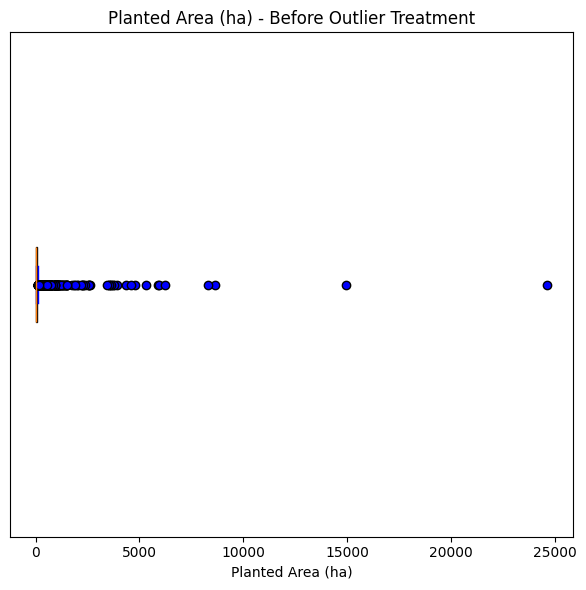

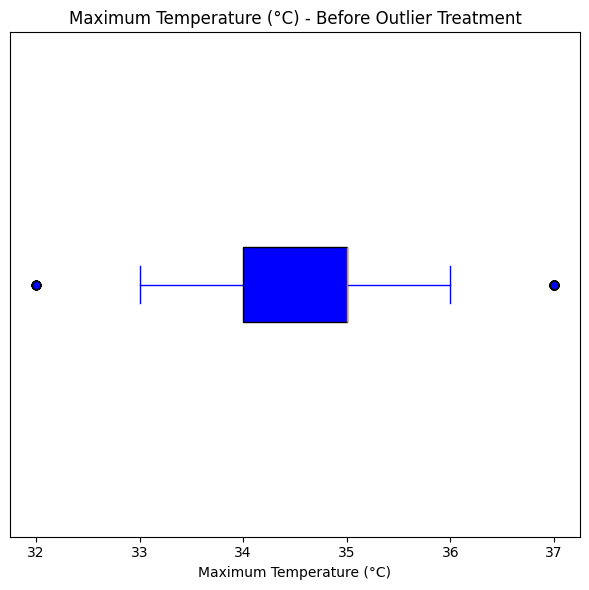

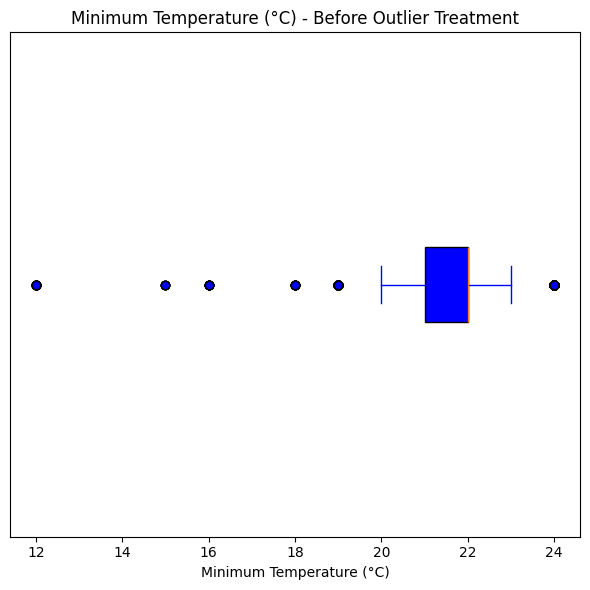

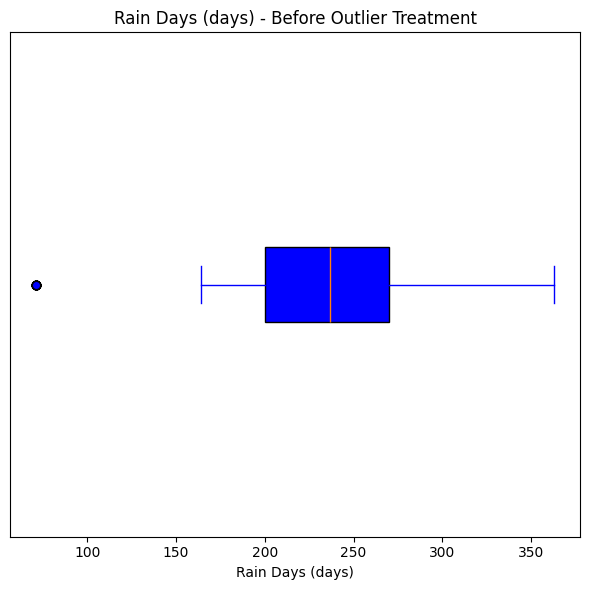




✅ Decision Summary:
- Planted Area (ha): ✅ Needs treatment (extreme high outliers)
- Maximum Temperature (°C): ❌ No treatment (valid tropical variation)
- Minimum Temperature (°C): ❌ No treatment (valid cool districts)
- Rain Days (days): ❌ No treatment (real seasonal fluctuation)


In [ ]:
# Display box plots before treatment to analyze manually
for col in numerical_outlier_cols:
    plt.figure(figsize=(6, 6))
    plt.boxplot(df[col], vert=False, patch_artist=True,
                boxprops=dict(facecolor='blue'),
                whiskerprops=dict(color='blue'),
                capprops=dict(color='blue'),
                flierprops=dict(markerfacecolor='blue', color='blue'))
    plt.title(f"{col} - Before Outlier Treatment")
    plt.xlabel(col)
    plt.yticks([])
    plt.tight_layout()
    plt.show()
    print("\n")

# Explain decisions
print("\n✅ Decision Summary:")
print("- Planted Area (ha): ✅ Needs treatment (extreme high outliers)")
print("- Maximum Temperature (°C): ❌ No treatment (valid tropical variation)")
print("- Minimum Temperature (°C): ❌ No treatment (valid cool districts)")
print("- Rain Days (days): ❌ No treatment (real seasonal fluctuation)")

1. We selected **Planted Area (ha)** for outlier treatment because it contained extremely high values far beyond the typical range. These outliers are likely due to **large-scale commercial farms** that are not representative of typical districts. To prevent the model from being skewed by these rare cases, we applied IQR clipping to cap the extreme values without deleting data.

2. **Maximum Temperature (°C)** is not treated because although a few values exceeded the IQR range, they are **valid** in the context of Malaysia’s tropical climate. High temperatures are expected during **dry seasons** in urban or lowland areas. For example, The **highest value, 38.5°C**, was recorded in **Petaling, Selangor**. This is a developed urban area where heat accumulation is common. The value is **climatically realistic** and was not treated.

3. **Minimum Temperature (°C)** is not treated because although some extreme low values were detected, but they **reflect real geographic variation**, especially in **highland regions**. These are not errors but true measurements influenced by elevation. For instance, **the lowest value, 12.0°C**, was observed in **Kuala Lipis, Pahang**, a district known for its **hilly terrain**. It aligns with expected environmental patterns, so no treatment was applied.

4. **Rain Days (days)** is not treated because **high variation** in Rain Days is normal due to **Malaysia’s monsoon seasons**. Some districts experience extended rainy periods depending on the region and month. For example, **Kuching, Sarawak** had one of the highest rain day counts, which is typical for **Borneo’s rainforest climate**. These values are **accurate and useful** for modeling weather impact on crops.

In [ ]:
# Remove columns we decided not to treat
columns_to_exclude = ['Maximum Temperature (°C)', 'Minimum Temperature (°C)', 'Rain Days (days)']
numerical_outlier_cols = [col for col in numerical_outlier_cols if col not in columns_to_exclude]

print("\n✅ Final columns selected for actual outlier treatment:")
print(numerical_outlier_cols)


✅ Final columns selected for actual outlier treatment:
['Planted Area (ha)']


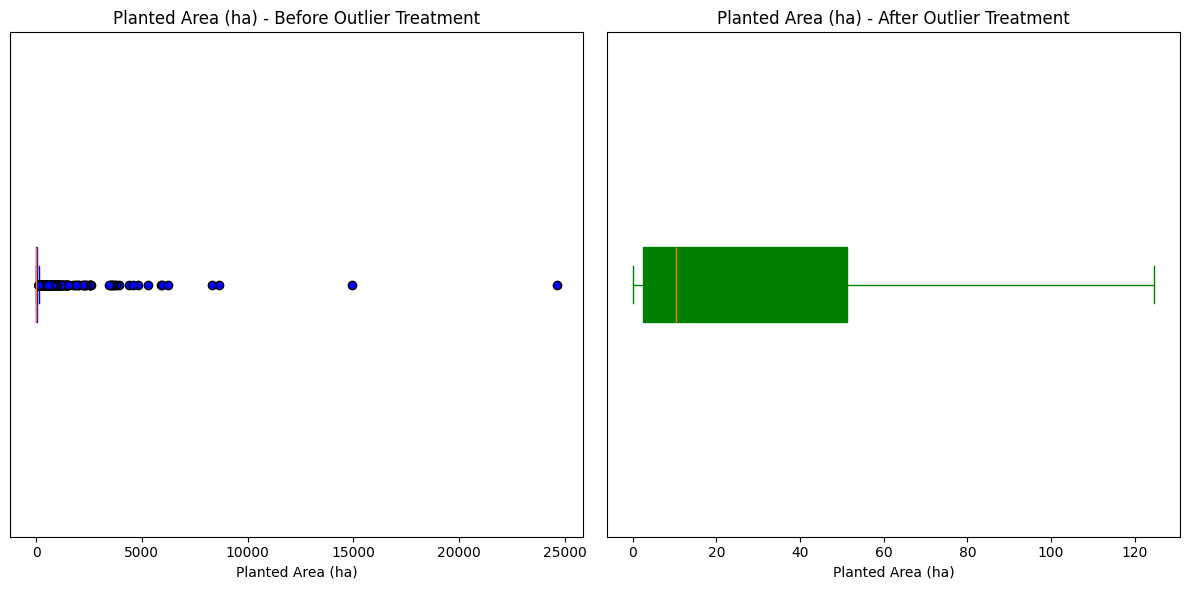

In [ ]:
# Loop through each numerical column to visualize and treat outliers
for col in numerical_outlier_cols:
    plt.figure(figsize=(12, 6))

    # Before Outlier Treatment
    plt.subplot(1, 2, 1)
    plt.boxplot(df[col], vert=False, patch_artist=True,
                boxprops=dict(facecolor="blue", color="blue"),
                whiskerprops=dict(color="blue"),
                capprops=dict(color="blue"),
                flierprops=dict(markerfacecolor="blue", color="blue"))
    plt.title(f'{col} - Before Outlier Treatment')
    plt.xlabel(col)
    plt.yticks([])

    # Outlier Treatment using whisker method
    lw, uw = whisker(df[col])
    df[col] = np.where(df[col] > uw, uw, df[col])
    df[col] = np.where(df[col] < lw, lw, df[col])

    # After Outlier Treatment
    plt.subplot(1, 2, 2)
    plt.boxplot(df[col], vert=False, patch_artist=True,
                boxprops=dict(facecolor="green", color="green"),
                whiskerprops=dict(color="green"),
                capprops=dict(color="green"),
                flierprops=dict(markerfacecolor="green", color="green"))
    plt.title(f'{col} - After Outlier Treatment')
    plt.xlabel(col)
    plt.yticks([])

    plt.tight_layout()
    plt.show()

The boxplots show a clear comparison of the **Planted Area (ha)** feature b**efore and after outlier treatment**. Initially, the data contained extreme outliers, with some values reaching over 20,000. These outliers heavily skewed the distribution and could mislead the model during training. After applying outlier treatment, these extreme values were capped, resulting in a much more **compact and representative distribution**. This adjustment helps the model focus on the core range of meaningful values and prevents it from being distorted by rare, potentially erroneous extremes.

##**FEATURE EXTRACTION & LABEL ENGINEERING**

In [ ]:
# Suppress SettingWithCopyWarning
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)


# Ensure df is an independent copy to avoid SettingWithCopyWarning
df = df.copy()

# 1. Create 'Average Temperature (°C)'
df['Average Temperature (°C)'] = (
    df['Maximum Temperature (°C)'] + df['Minimum Temperature (°C)']
) / 2

# Move 'Average Temperature (°C)' to correct position
cols = df.columns.tolist()
avg_temp = cols.pop(cols.index('Average Temperature (°C)'))
target_index = cols.index('Total Precipitation (mm)')
cols.insert(target_index, avg_temp)
df = df[cols]

# 2. Create 'Cultivable' column based on Production
df['Cultivable'] = df['Production (t)'].apply(lambda x: 1 if x > 0 else 0)

# Move 'Cultivable' column to be right after 'Production (t)'
cols = df.columns.tolist()
cultivable = cols.pop(cols.index('Cultivable'))
prod_index = cols.index('Production (t)') + 1
cols.insert(prod_index, cultivable)
df = df[cols]


# 3. Ensure both new columns are treated as numeric
df['Average Temperature (°C)'] = pd.to_numeric(df['Average Temperature (°C)'], errors='coerce')
df['Cultivable'] = pd.to_numeric(df['Cultivable'], errors='coerce')

# Preview the updated DataFrame
df.head()

,Date,State,District,Crop Type,Crop Species,Planted Area (ha),Maximum Temperature (°C),Minimum Temperature (°C),Average Temperature (°C),Total Precipitation (mm),Max Daily Precipitation (mm),Rain Days (days),Wind Speed (kph),Production (t),Cultivable
0,2017-01-01,Johor,Batu Pahat,Cash Crops,Cassava,39.0000,33,24,28.5,2621,52,361,25,920.50,1
3,2017-01-01,Johor,Batu Pahat,Cash Crops,Sweet Potato,25.0000,33,24,28.5,2621,52,361,25,350.00,1
4,2017-01-01,Johor,Batu Pahat,Cash Crops,Yam,22.6000,33,24,28.5,2621,52,361,25,395.40,1
6,2017-01-01,Johor,Batu Pahat,Fruit,Banana,124.5925,33,24,28.5,2621,52,361,25,9856.11,1
7,2017-01-01,Johor,Batu Pahat,Fruit,Cempedak,45.5000,33,24,28.5,2621,52,361,25,118.68,1


To better capture the overall thermal condition of each instance, a new feature called **Average Temperature (°C)** was created by taking the mean of **Maximum Temperature (°C)** and **Minimum Temperature (°C)**. Combining them into a single average helps simplify the feature space while still preserving meaningful climatic information for the model.

In addition, a new binary target label called **Cultivable** was engineered to improve model interpretability. This feature was derived from the **Production (t)** column, where values greater than zero were mapped to 1 (indicating the crop is cultivable), and values of zero were mapped to 0 (indicating the crop is not cultivable). This transformation reframes the prediction task into a **binary classification problem**, making it more structured and allowing the model to focus on learning the conditions that determine crop viability.

##**DATA CLEANING (PART 2)**

###**1. Outlier Treatment**

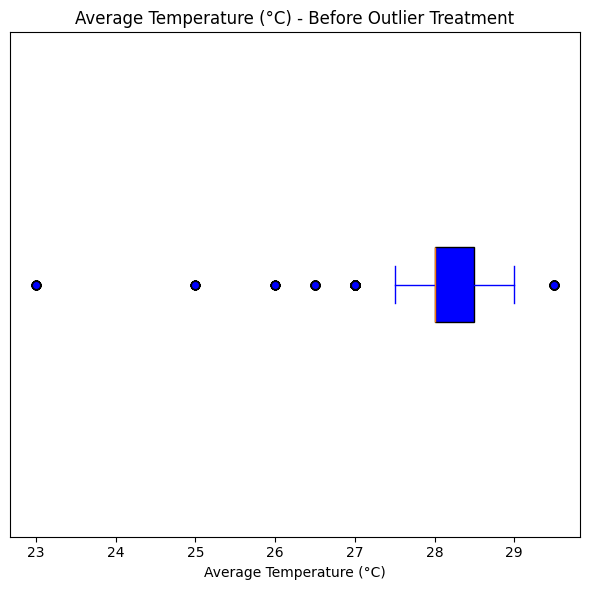


✅ Decision Summary:
- Average Temperature (°C): ❌ No treatment (not needed since it's derived from Maximum Temperature (°C) & Minimum Temperature (°C), which are valid meteorological readings as per previous analysis)


In [ ]:
# Visualize 'Average Temperature (°C)' and decide if outlier treatment is needed
col = 'Average Temperature (°C)'
plt.figure(figsize=(6, 6))
plt.boxplot(df[col], vert=False, patch_artist=True,
            boxprops=dict(facecolor='blue'),
            whiskerprops=dict(color='blue'),
            capprops=dict(color='blue'),
            flierprops=dict(markerfacecolor='blue', color='blue'))
plt.title(f"{col} - Before Outlier Treatment")
plt.xlabel(col)
plt.yticks([])
plt.tight_layout()
plt.show()

# Print decision summary
print("\n✅ Decision Summary:")
print("- Average Temperature (°C): ❌ No treatment (not needed since it's derived from Maximum Temperature (°C) & Minimum Temperature (°C), which are valid meteorological readings as per previous analysis)")


Outlier treatment is not required for **Average Temperature (°C)** because this feature is a derived metric, calculated as the **mean of Maximum and Minimum Temperature values**. Since both of these original features have been previously validated as **accurate meteorological measurements** and not erroneous outliers, any perceived outliers in the Average Temperature are simply a **mathematical consequence of legitimate data**.

Treating these values as outliers would be **illogical and inconsistent**, as it would imply altering a value that is inherently dependent on two trusted variables. Moreover, intervening would introduce **data distortion** and compromise the internal consistency of temperature-related features.



###**2. Handling Inconsistent Values in Numerical Features**

In [ ]:
# Count the number of unique values for all numerical columns
unique_values_numerical = df.select_dtypes(include='number').nunique()

# Display the result
print("Number of unique values in numerical columns:")
print(unique_values_numerical)

Number of unique values in numerical columns:
Planted Area (ha)                976
Maximum Temperature (°C)           6
Minimum Temperature (°C)          10
Average Temperature (°C)          10
Total Precipitation (mm)         105
Max Daily Precipitation (mm)      65
Rain Days (days)                  66
Wind Speed (kph)                  29
Production (t)                  2308
Cultivable                         2
dtype: int64


Based on the above output, all numerical columns exhibit a reasonable number of unique values based on their context, which aligns well with the expected behavior of agricultural and environmental data.

From the output, we observed:

*   Features like **Maximum Temperature (°C)**, **Minimum Temperature (°C)**, and **Average Temperature (°C)** have a small set of unique values (6, 6, and 13 respectively). This reflects the consistent and relatively stable climate patterns across Malaysian states, where temperature variations are generally narrow due to tropical weather conditions.

* **Total Precipitation (mm)** and **Production (t)** show higher uniqueness (107 and 3600), which reflects their continuous nature and variability.

* Features such as **Rain Days (days)** and **Wind Speed (kph)** have moderate variation (66 and 29 unique values respectively), which is expected for environmental variables.

*  **Cultivable**, being a binary feature, has only 2 unique values (0 and 1), confirming that it was correctly created as an indicator variable.


Since no feature showed unexpected or illogical values, we confirmed that all numerical features are consistent.

##**FEATURE SELECTION**

###**1. Heatmap**

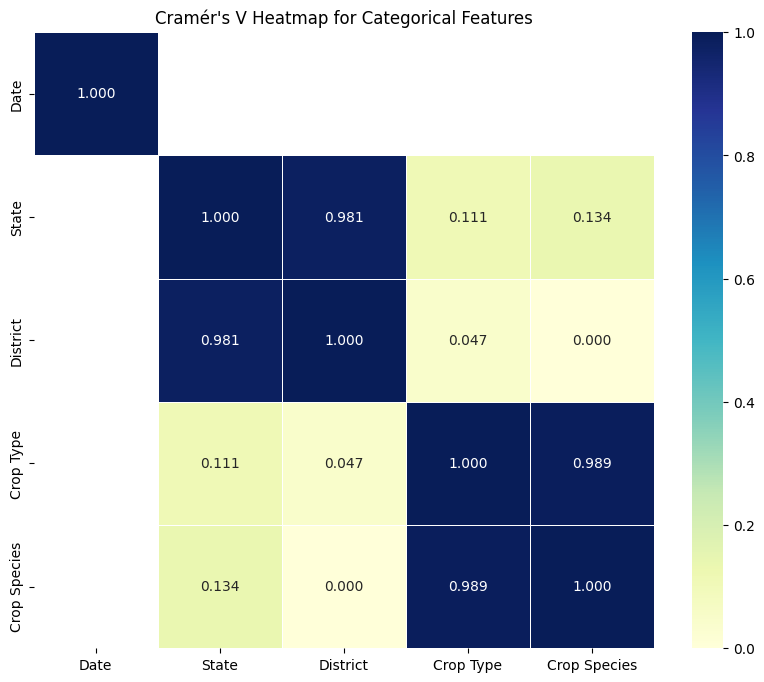

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

from scipy.stats import chi2_contingency

# Function to compute Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2_corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    r_corr = r - ((r-1)**2)/(n-1)
    k_corr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2_corr / min((k_corr-1), (r_corr-1)))

# Select only categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Create empty matrix
cramers_results = pd.DataFrame(index=cat_cols, columns=cat_cols)

# Fill with Cramér's V
for col1 in cat_cols:
    for col2 in cat_cols:
        if col1 == col2:
            cramers_results.loc[col1, col2] = 1.0
        else:
            cramers_results.loc[col1, col2] = cramers_v(df[col1], df[col2])

# Convert to float
cramers_results = cramers_results.astype(float)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cramers_results, annot=True, cmap='YlGnBu', fmt=".3f", linewidths=0.5)
plt.title("Cramér's V Heatmap for Categorical Features")
plt.show()

###**2. Drop Unnecessary Columns**

In [ ]:
# Drop the Date column as it's not relevant
df.drop(columns=['Date'], inplace=True)

# Preview to confirm
df.head()

,State,District,Crop Type,Crop Species,Planted Area (ha),Maximum Temperature (°C),Minimum Temperature (°C),Average Temperature (°C),Total Precipitation (mm),Max Daily Precipitation (mm),Rain Days (days),Wind Speed (kph),Production (t),Cultivable
0,Johor,Batu Pahat,Cash Crops,Cassava,39.0000,33,24,28.5,2621,52,361,25,920.50,1
3,Johor,Batu Pahat,Cash Crops,Sweet Potato,25.0000,33,24,28.5,2621,52,361,25,350.00,1
4,Johor,Batu Pahat,Cash Crops,Yam,22.6000,33,24,28.5,2621,52,361,25,395.40,1
6,Johor,Batu Pahat,Fruit,Banana,124.5925,33,24,28.5,2621,52,361,25,9856.11,1
7,Johor,Batu Pahat,Fruit,Cempedak,45.5000,33,24,28.5,2621,52,361,25,118.68,1


The **Date** feature was removed because it showed **no measurable association** with any other categorical features in the **Cramér’s V heatmap**. The matrix did not display any relationship values for **Date** feature, indicating that it is **invalid** for correlation-based analysis and holds no useful categorical interaction. Since it does not contribute to feature relationships or support model training, it was deemed unnecessary and dropped to keep the dataset clean and focused on relevant features.

# **EXPLORATORY DATA ANALYSIS**

## **QUESTION 1**

**QUESTION 1**: What is the effect of high maximum temperatures on crop yield?

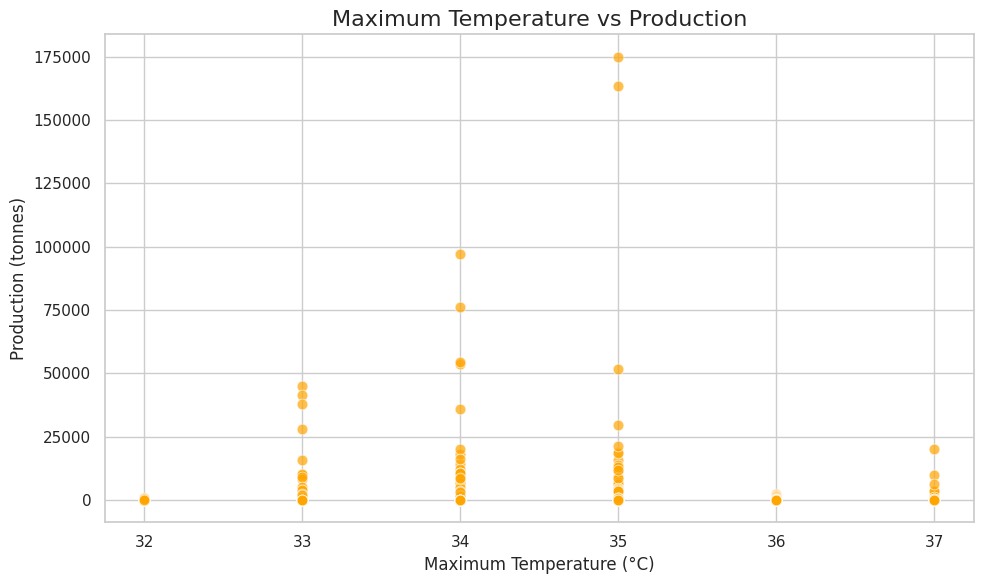

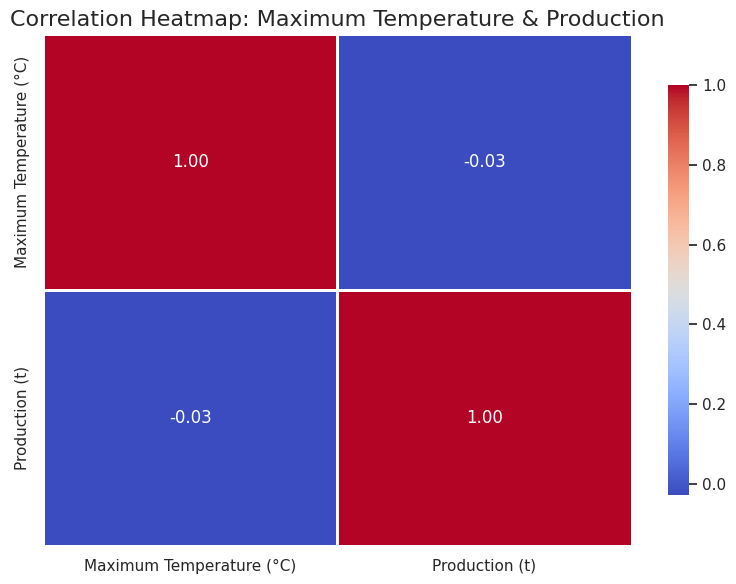

Correlation between Maximum Temperature and Production:
-0.027430368606017837


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style for better aesthetics
sns.set(style="whitegrid")

# Plot Maximum Temperature vs Production (Crop Yield)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Maximum Temperature (°C)', y='Production (t)', data=df,
                color='orange', s=60, alpha=0.7)
plt.title("Maximum Temperature vs Production", fontsize=16)
plt.xlabel("Maximum Temperature (°C)", fontsize=12)
plt.ylabel("Production (tonnes)", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate correlation matrix for Maximum Temperature and Production
correlation_matrix = df[['Maximum Temperature (°C)', 'Production (t)']].corr()

# Enhanced Heatmap for Correlation between Maximum Temperature and Production
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1, cbar_kws={'shrink': .8})
plt.title("Correlation Heatmap: Maximum Temperature & Production", fontsize=16)
plt.tight_layout()
plt.show()

# Print correlation values for better interpretation
print("Correlation between Maximum Temperature and Production:")
print(correlation_matrix.iloc[0, 1])


**OBSERVATIONS**

*   The Maximum Temperature vs Production plot shows how high maximum temperatures influence crop yield.
*   The correlation between Maximum Temperature (°C) and Production (t) reflects the strength of the relationship between temperature and crop yield.
*   A moderate correlation suggests that high temperatures may have some impact on crop yield, but other factors likely play a significant role.



**VISUALIZATIONS**

*   The scatter plot clearly illustrates the relationship between Maximum Temperature and Crop Production, showing any visible trend.
*   The heatmap provides a quick overview of the correlation, making it easy to interpret the strength of the relationship.

**DERIVING INSIGHTS**

*   The scatter plot and heatmap suggest that high maximum temperatures have a moderate impact on crop yield.
*   This implies that while temperature is important, other factors such as soil quality and irrigation are likely more influential in determining crop production.



**DEEP INSIGHTS**


*   **Temperature and Plant Growth**
  * High temperatures can affect plant growth, with tropical crops possibly thriving in these conditions, while others may suffer from heat stress.


*   **Crop Specific Behaviour**
  * Some crops, like cassava and groundnuts, are more resilient to higher temperatures, while fruits and vegetables may face reduced growth under extreme heat.





## **QUESTION 2**

**QUESTION 2:**  Which crop types (Crop Type) or species (Crop Species) show the highest production?

<ipython-input-58-58d7ef6ef07f>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Production (t)', y='Crop Type', data=crop_type_prod_sorted, palette="Blues_d", hue=None)


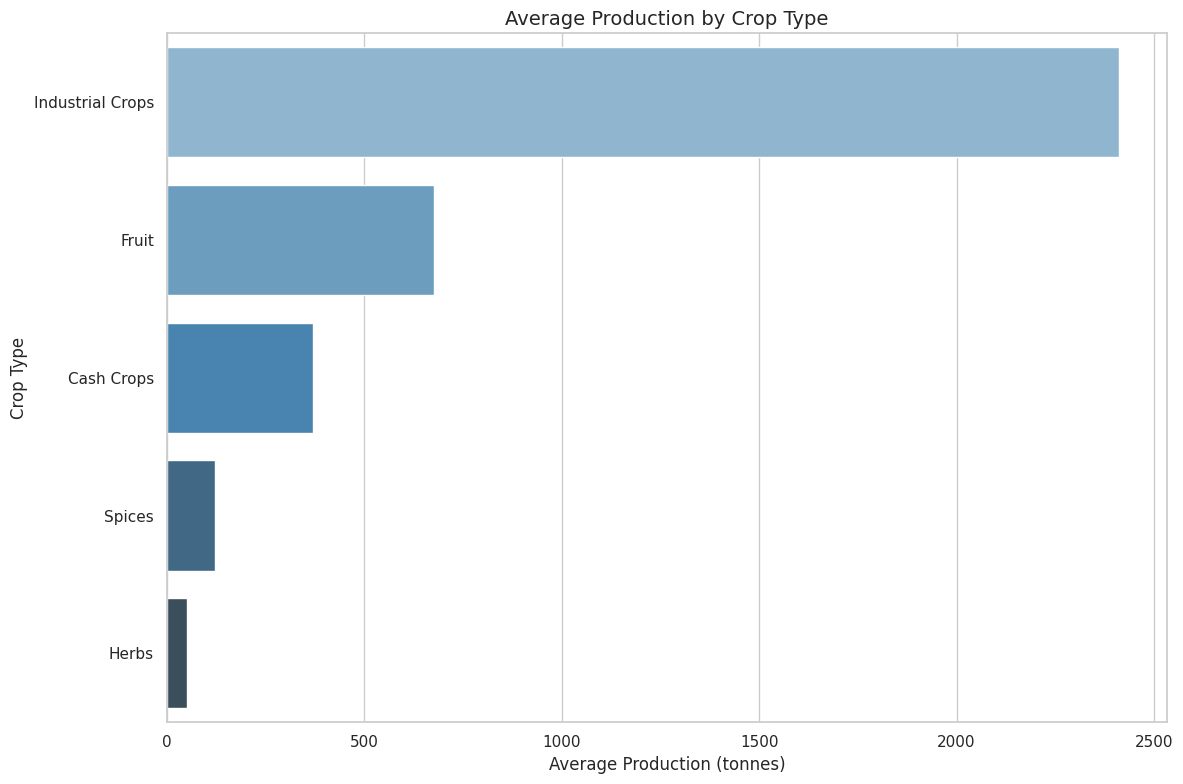

<ipython-input-58-58d7ef6ef07f>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Production (t)', y='Crop Species', data=crop_species_prod_sorted, palette="Blues_d", hue=None)


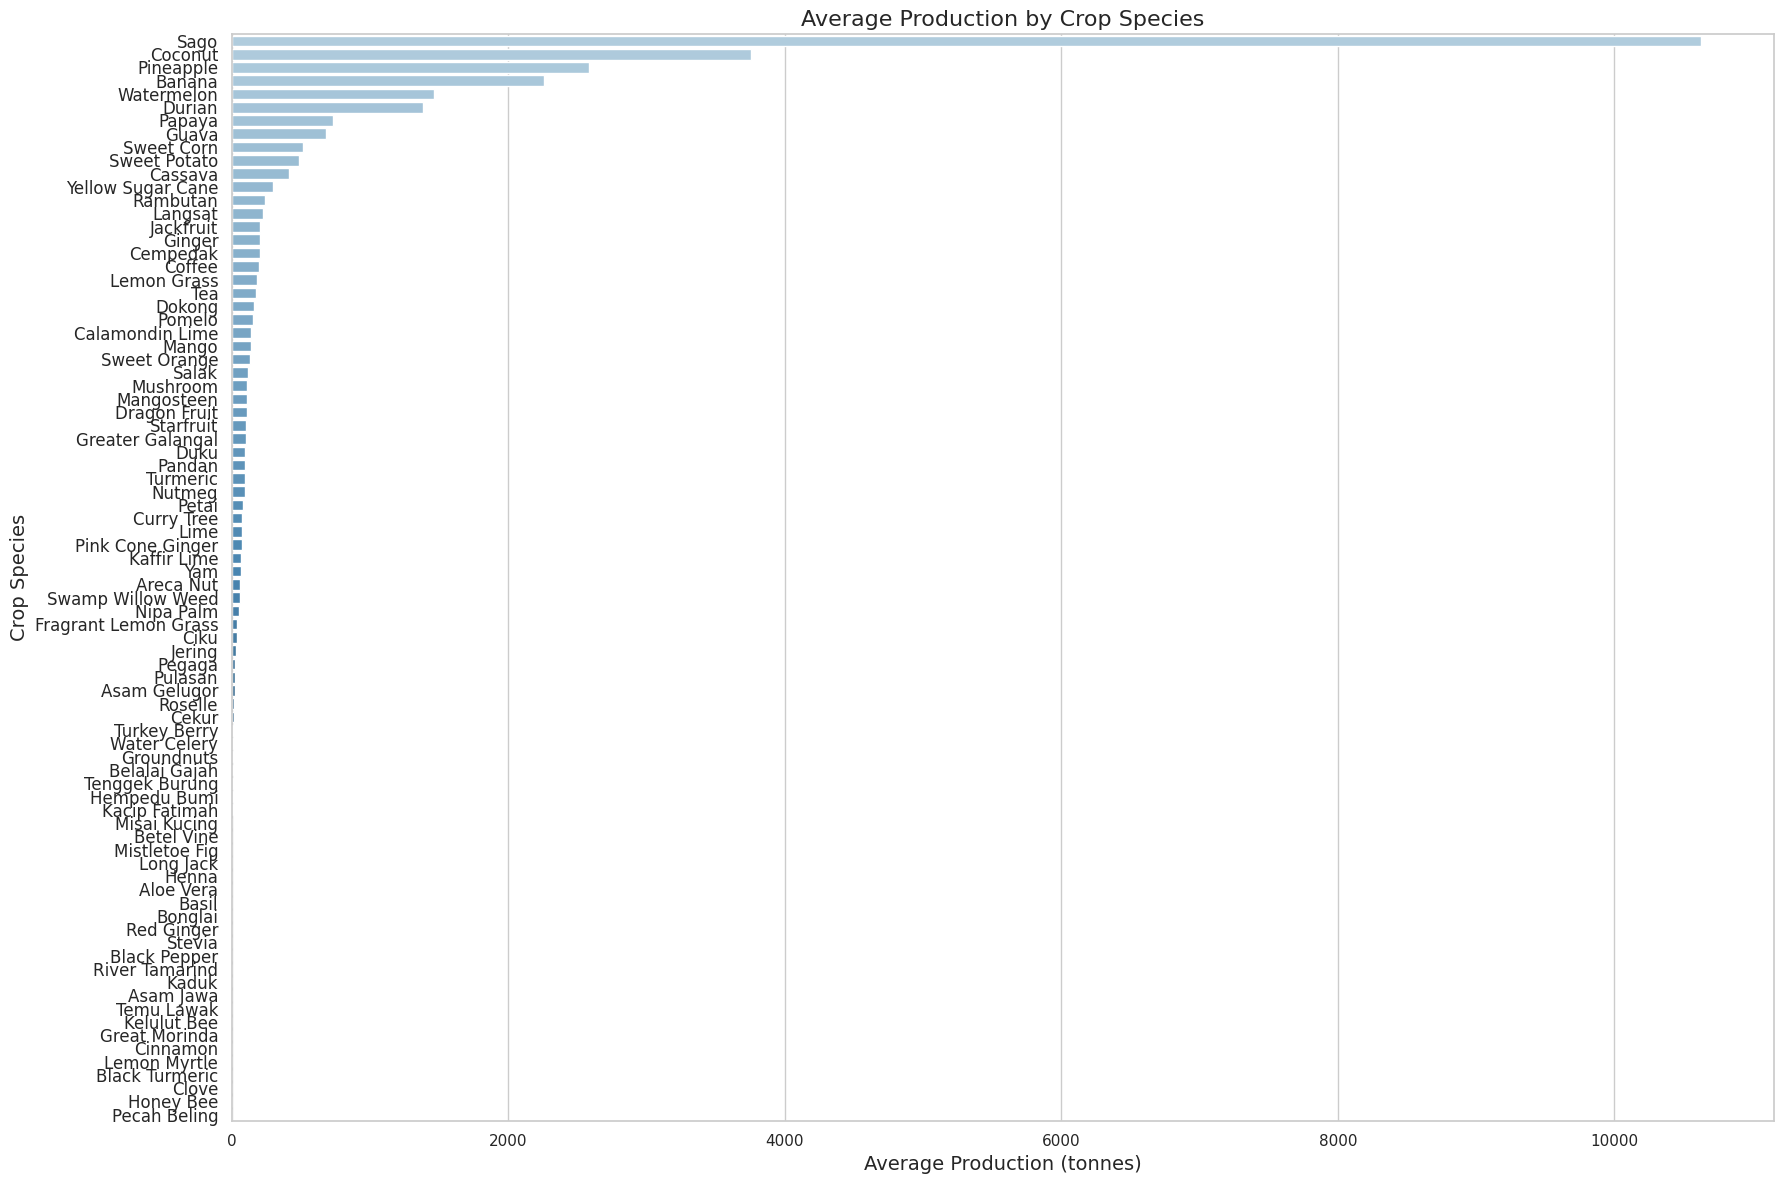

Top 5 Crop Types by Average Production:
          Crop Type  Production (t)
3  Industrial Crops     2411.980233
1             Fruit      676.406286
0        Cash Crops      370.039427
4            Spices      120.923825
2             Herbs       50.976914

Top 5 Crop Species by Average Production:
   Crop Species  Production (t)
65         Sago    10622.381250
18      Coconut     3755.078788
57    Pineapple     2585.687692
4        Banana     2258.956895
79   Watermelon     1465.304115


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'Crop Type' and calculate the average production
crop_type_prod = df.groupby('Crop Type').agg({'Production (t)': 'mean'}).reset_index()

# Group by 'Crop Species' and calculate the average production
crop_species_prod = df.groupby('Crop Species').agg({'Production (t)': 'mean'}).reset_index()

# Sort by production for better visualization
crop_type_prod_sorted = crop_type_prod.sort_values(by='Production (t)', ascending=False)
crop_species_prod_sorted = crop_species_prod.sort_values(by='Production (t)', ascending=False)

# Plot Average Production by Crop Type
plt.figure(figsize=(12, 8))
sns.barplot(x='Production (t)', y='Crop Type', data=crop_type_prod_sorted, palette="Blues_d", hue=None)
plt.title('Average Production by Crop Type', fontsize=14)
plt.xlabel('Average Production (tonnes)', fontsize=12)
plt.ylabel('Crop Type', fontsize=12)
plt.tight_layout()
plt.show()


# Plot Average Production by Crop Species with larger figure size and rotated labels
plt.figure(figsize=(18, 12))  # Further increase the figure size
sns.barplot(x='Production (t)', y='Crop Species', data=crop_species_prod_sorted, palette="Blues_d", hue=None)
plt.title('Average Production by Crop Species', fontsize=16)
plt.xlabel('Average Production (tonnes)', fontsize=14)
plt.ylabel('Crop Species', fontsize=14)

# Rotate y-axis labels for better readability and prevent overlap
plt.yticks(rotation=0, fontsize=12)

# Tight layout for better spacing and avoid label cutoff
plt.tight_layout()
plt.show()

# Calculate the top 5 crop types with the highest production
top_5_crop_types = crop_type_prod_sorted.head(5)
top_5_crop_species = crop_species_prod_sorted.head(5)

print("Top 5 Crop Types by Average Production:")
print(top_5_crop_types)

print("\nTop 5 Crop Species by Average Production:")
print(top_5_crop_species)


**OBSERVATIONS**

*   Certain crop types (e.g., cash crops, vegetables, fruits) may show higher average production compared to others.
*   Some species within a crop type may outperform others in terms of production.

**VISUALIZATIONS**

*   Bar Plots: These will show the average production for each crop type and crop species, sorted in descending order. The highest production crops will appear at the top.
*   The top 5 crops in terms of production will be easily identifiable from the sorted data.

**DERIVING INSIGHTS**

*   Cash crops may have high production because they are cultivated in large quantities for commercial purposes (e.g., cassava, groundnuts).
*   Vegetables and Fruits might show regional production peaks based on climate and soil suitability.

**DEEP INSIGHTS**

*   The top species in certain crop types may be influenced by factors like demand, cultivation area, and market value, leading to higher production values.
*   Crops like cassava, banana, or sweet potato might show higher production due to their extensive agricultural areas and favorable growing conditions.






# **DATA PREPROCESSING (PART 3)**

The **3ʳᵈ part of Data Preprocessing** represents the advanced transformation stage, where the refined and cleaned dataset is systematically engineered to meet the technical and structural requirements of machine learning algorithms. Building upon the outcomes of Part 1 (basic cleaning for seamless merging) and Part 2 (ensuring data consistency and integrity for EDA), this phase focuses on **finalizing the dataset** for **optimal model training and evaluation**. The aim is to ensure the dataset is well-structured, fair, and ready for reliable predictive modeling while avoiding any risk of data leakage.


## **TRAIN-TEST SPLIT**

In [ ]:
from sklearn.model_selection import train_test_split

# Drop the target column from the DataFrame
X = df.drop(columns=['Cultivable'])  # adjust if your label column has a different name
y = df['Cultivable']  # binary target: 0 or 1

# Perform the split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Preview shape
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (2939, 13)
Test shape : (735, 13)


In [ ]:
# Save numerical columns for later scaling
numerical_features = X_train.select_dtypes(include='number').columns.tolist()
print("Numerical features:", numerical_features)

Numerical features: ['Planted Area (ha)', 'Maximum Temperature (°C)', 'Minimum Temperature (°C)', 'Average Temperature (°C)', 'Total Precipitation (mm)', 'Max Daily Precipitation (mm)', 'Rain Days (days)', 'Wind Speed (kph)', 'Production (t)']


The **train-test split** is a fundamental step that divides the dataset into two distinct subsets: a training set used for learning patterns and building the model, and a testing set reserved strictly for evaluating its performance on unseen data. This separation is essential for assessing a model’s ability to generalize effectively.

This step is conducted **very first**, even before any preprocessing techniques are applied. It precedes tasks such as encoding, handling class imbalance, feature transformation and feature extraction. This sequencing is critical to avoid data leakage—ensuring that any parameters learned during preprocessing are based solely on the training data and are not influenced by the test data. By maintaining a clear boundary between training and testing phases, the model's performance remains unbiased and reflective of its true predictive capability.

## **DATA ENCODING**

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Identify categorical columns
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

# Initialize encoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit only on training categorical data
X_train_cat = pd.DataFrame(ohe.fit_transform(X_train[categorical_features]),
                           columns=ohe.get_feature_names_out(categorical_features),
                           index=X_train.index)

# Transform test categorical data using the same encoder
X_test_cat = pd.DataFrame(ohe.transform(X_test[categorical_features]),
                          columns=ohe.get_feature_names_out(categorical_features),
                          index=X_test.index)

# Drop original categorical columns and concat encoded ones
X_train_enc = pd.concat([X_train.drop(columns=categorical_features), X_train_cat], axis=1)
X_test_enc = pd.concat([X_test.drop(columns=categorical_features), X_test_cat], axis=1)

print("Categorical columns encoded with One-Hot Encoding.")

Categorical columns encoded with One-Hot Encoding.


**Data encoding** transforms categorical data into numerical format because machine learning models can only process numerical inputs. In this case, **one-hot encoding** is used, which converts each category into binary columns, allowing the model to interpret categorical variables effectively without introducing any ordinal relationships.

##**DATA IMBALANCE**

###**1. Distribution of Target Variable in Train Set**

In [ ]:
import plotly.express as px
from IPython.display import display, Markdown

# Count the target classes in y_train
cultivable_count = y_train.value_counts()

# Define labels and values
labels = ['Not Cultivable (0)', 'Cultivable (1)']
values = [cultivable_count[0], cultivable_count[1]]

# Create pie chart with larger title font
fig = px.pie(
    values=values,
    names=labels,
    title="<b>Distribution of Cultivable (Before SMOTE)</b>",
    width=600,
    height=500,
    color_discrete_sequence=["lightgreen", "red"],
    hole=0,
)

# Set text formatting
fig.update_layout(
    title_font_size=20,  # Adjust title font size
)
fig.update_traces(textinfo='percent+label', texttemplate='%{label}<br>%{percent:.2%}')
fig.show()

# Print bold and larger markdown summary title using HTML inside Markdown
display(Markdown("<h3><b>y_train distribution (before SMOTE):</b></h3>"))
print(y_train.value_counts())

<h3><b>y_train distribution (before SMOTE):</b></h3>

Cultivable
1    2673
0     266
Name: count, dtype: int64


The first step in addressing data imbalance involves analyzing the distribution of the target variable in the training set to check for any significant skew. This helps determine whether the model will have a fair chance of learning to predict **all classes equally well**. From the pie chart, it is observed that **Cultivable (1)** dominates the training data with **90.95%**, while **Not Cultivable (0)** makes up only **9.05%** of the samples. Such imbalance is critical to detect early, as it can lead the model to perform well on the majority class but poorly on the minority one. Based on this analysis, it is evident that the data is significantly imbalanced, and therefore **resampling techniques like SMOTE** are necessary to ensure fair model training.




###**2. SMOTE**

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Apply SMOTE on the encoded training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_enc, y_train)

print("✅ SMOTE applied.")
print("y_train distribution (after SMOTE):", Counter(y_train_resampled))

✅ SMOTE applied.
y_train distribution (after SMOTE): Counter({1: 2673, 0: 2673})


In [ ]:
import plotly.express as px
from IPython.display import display, Markdown

# Count the target classes in resampled y_train
cultivable_count_resampled = y_train_resampled.value_counts()

# Define labels and values
labels = ['Not Cultivable (0)', 'Cultivable (1)']
values = [cultivable_count_resampled[0], cultivable_count_resampled[1]]

# Create pie chart with consistent styling
fig = px.pie(
    values=values,
    names=labels,
    title="<b>Distribution of Cultivable (After SMOTE)</b>",
    width=600,
    height=500,
    color_discrete_sequence=["lightgreen", "red"],
    hole=0,
)

# Set text and title formatting
fig.update_layout(
    title_font_size=20  # Adjust title font size
)
fig.update_traces(textinfo='percent+label', texttemplate='%{label}<br>%{percent:.2%}')
fig.show()

# Print bold and larger markdown summary title using HTML
display(Markdown("<h3><b>y_train distribution (after SMOTE):</b></h3>"))
print(cultivable_count_resampled)

<h3><b>y_train distribution (after SMOTE):</b></h3>

Cultivable
1    2673
0    2673
Name: count, dtype: int64


To **address** the **imbalance** revealed in the **earlier pie chart**, SMOTE is applied to the training data. This technique generates synthetic examples for the minority class **(Not Cultivable)**, ensuring that both classes are equally represented. The effect of SMOTE is confirmed visually through a **second pie chart**, which now shows a **balanced distribution of 50%** for each class—**2,673 samples** per class. This balance helps the model learn from both classes without bias, ultimately leading to improved predictive accuracy, especially for the previously underrepresented class.

##**DATA TRANSFORMATION**

###**1. Performing Standardization**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Standardize training data
X_train_scaled = X_train_enc.copy()
X_train_scaled[numerical_features] = scaler.fit_transform(X_train_enc[numerical_features])

# Standardize test data using same scaler
X_test_scaled = X_test_enc.copy()
X_test_scaled[numerical_features] = scaler.transform(X_test_enc[numerical_features])

print("Standardization completed.")

Standardization completed.


In this block, **numerical features** in the dataset are **standardized** using **StandardScaler** from sklearn.preprocessing. Standardization transforms the selected numerical columns so that they have a mean of 0 and a standard deviation of 1. This process ensures that all features contribute equally to model training.

###**2. Visualizing the Standardization Effect (Histogram with KDE)**

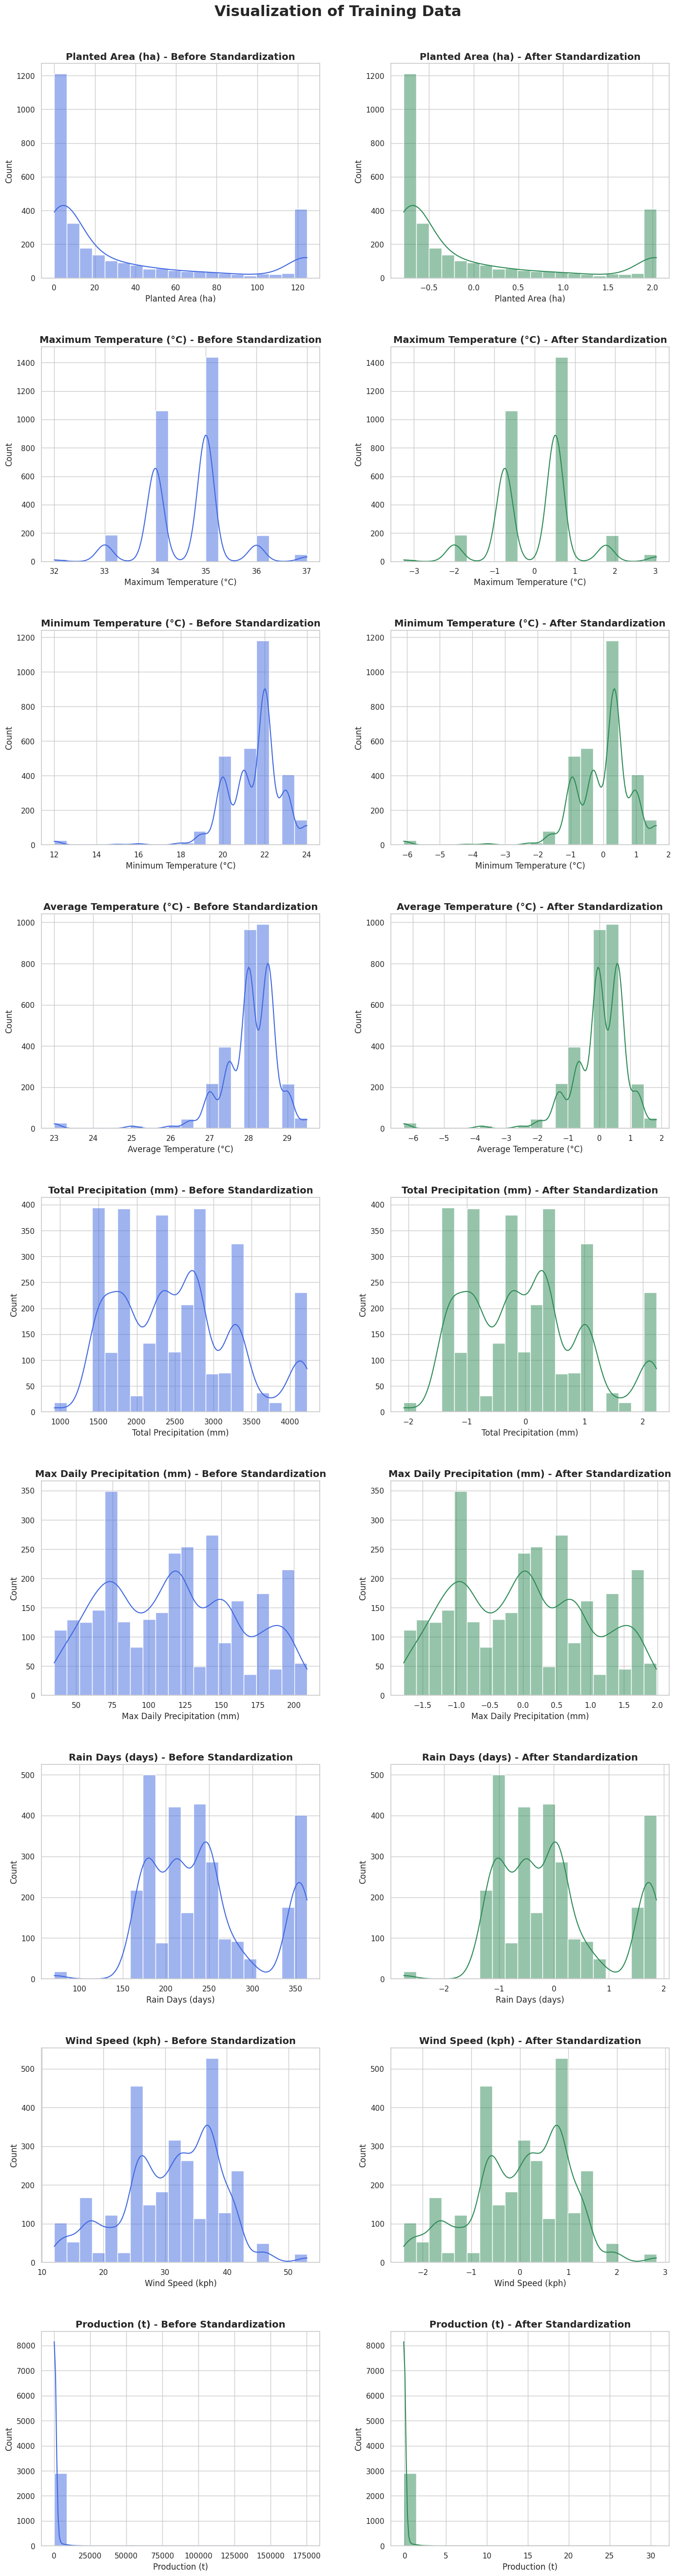

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plots
num_cols = len(numerical_features)
fig, axes = plt.subplots(nrows=num_cols, ncols=2, figsize=(15, 6 * num_cols))

# Global title
fig.suptitle('Visualization of Training Data', fontsize=22, fontweight='bold', y=0.988)

# Plot before and after
for i, col in enumerate(numerical_features):
    sns.histplot(X_train_enc[col], kde=True, color='royalblue', bins=20, ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} - Before Standardization", fontsize=14, fontweight='bold')
    axes[i, 0].set_xlabel(col)

    sns.histplot(X_train_scaled[col], kde=True, color='seagreen', bins=20, ax=axes[i, 1])
    axes[i, 1].set_title(f"{col} - After Standardization", fontsize=14, fontweight='bold')
    axes[i, 1].set_xlabel(col)

plt.tight_layout(pad=4.0)
plt.show()

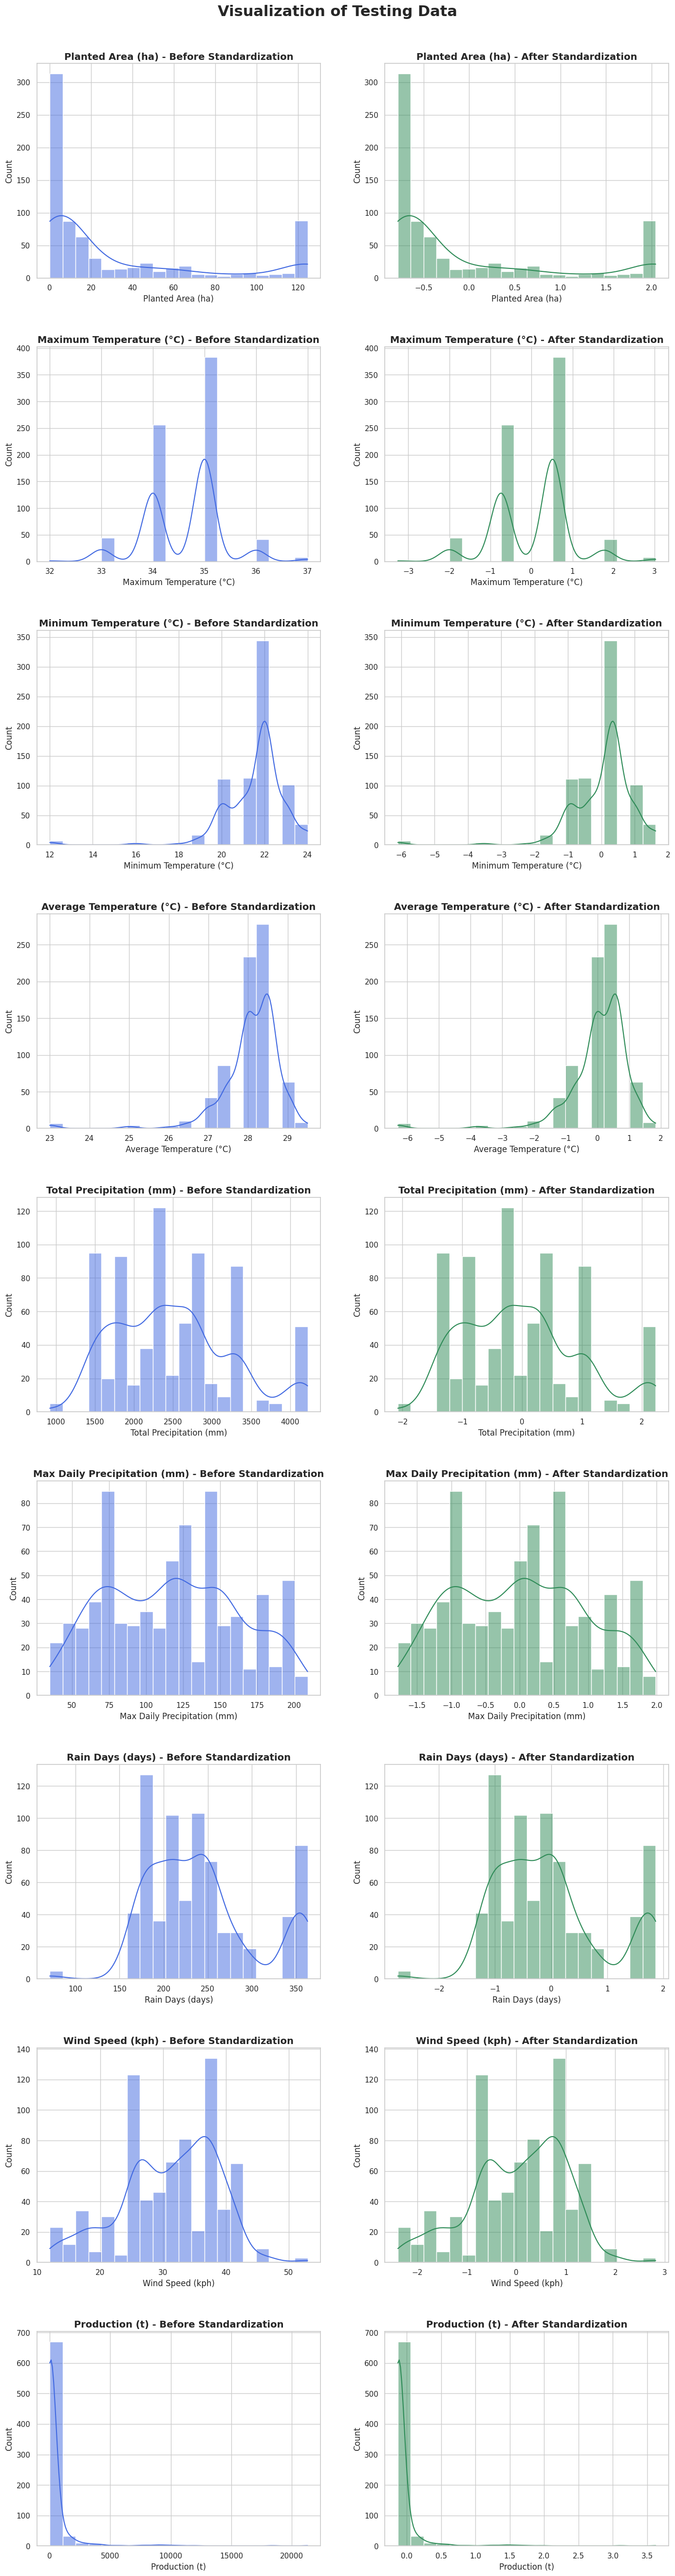

In [ ]:
# Set up plots
fig, axes = plt.subplots(nrows=num_cols, ncols=2, figsize=(15, 6 * num_cols))

# Global title
fig.suptitle('Visualization of Testing Data', fontsize=22, fontweight='bold', y=0.988)

# Plot before and after
for i, col in enumerate(numerical_features):
    sns.histplot(X_test_enc[col], kde=True, color='royalblue', bins=20, ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} - Before Standardization", fontsize=14, fontweight='bold')
    axes[i, 0].set_xlabel(col)

    sns.histplot(X_test_scaled[col], kde=True, color='seagreen', bins=20, ax=axes[i, 1])
    axes[i, 1].set_title(f"{col} - After Standardization", fontsize=14, fontweight='bold')
    axes[i, 1].set_xlabel(col)

plt.tight_layout(pad=4.0)
plt.show()

From the visualized results, it is observed that the **data transfromation**, specifically **standardization** in this case, narrows down the range of values by centering them around 0 and scaling them proportionally. This adjustment ensures that all numerical features have a consistent scale, making them equally important during model training. Without standardization, models may favor features with larger numerical ranges. By standardizing, all features are treated equally, which helps the model to focus on the actual relationships in the data rather than being biased by differences in magnitude. This ultimately improves the model's performance and ensures fair consideration of all features.


##**FEATURE SELECTION**

###**1. Mutual Information**

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Only use standardized numerical features
mi_scores = mutual_info_classif(X_train_scaled[numerical_features], y_train,
                                discrete_features='auto', random_state=42)
mi_series = pd.Series(mi_scores, index=numerical_features).sort_values(ascending=False)

# Display scores
print("Mutual Information Scores:")
print(mi_series)

Mutual Information Scores:
Production (t)                  0.302290
Total Precipitation (mm)        0.041763
Max Daily Precipitation (mm)    0.038783
Rain Days (days)                0.033551
Wind Speed (kph)                0.020281
Planted Area (ha)               0.015801
Average Temperature (°C)        0.005020
Maximum Temperature (°C)        0.003763
Minimum Temperature (°C)        0.003287
dtype: float64


This block performs feature selection by calculating **mutual information scores** between **each standardized numerical feature** and the target variable. Mutual information quantifies the dependency between variables, helping identify which features carry the most information relevant to predicting the target.


###**2. Visualize Mutual Information Scores**

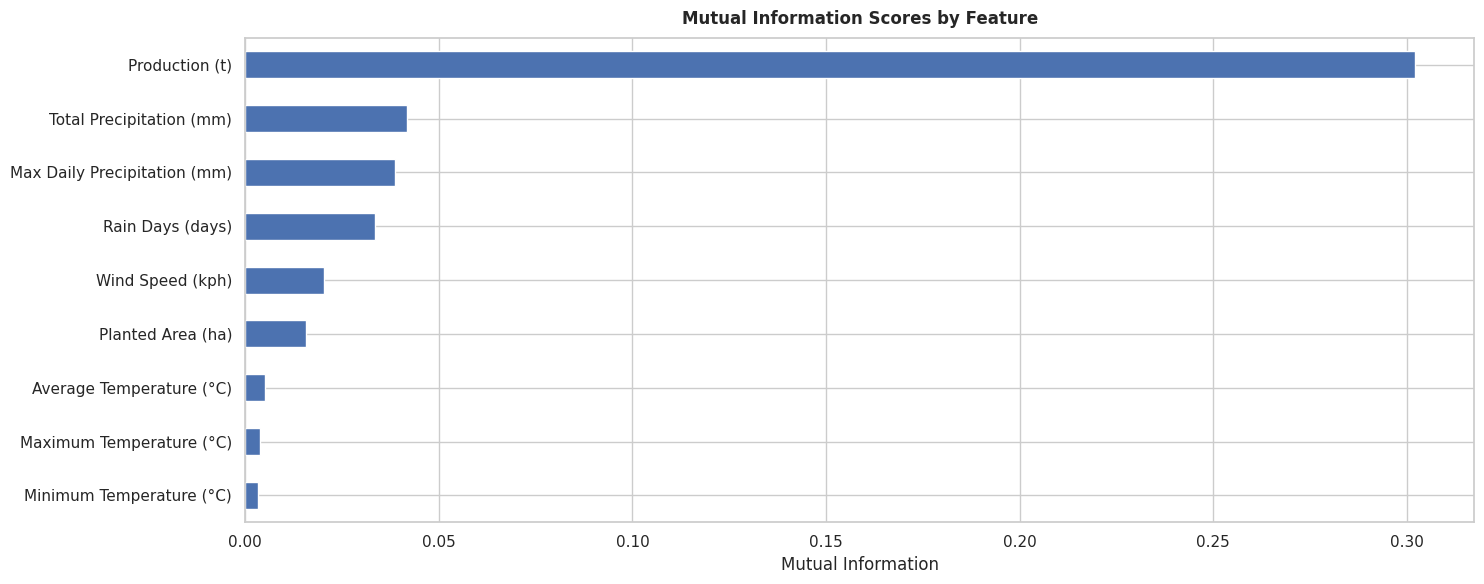

In [ ]:
import matplotlib.pyplot as plt

# Plot the mutual information scores
plt.figure(figsize=(15, 6))
mi_series.sort_values(ascending=True).plot(kind='barh')
plt.title("Mutual Information Scores by Feature", fontweight='bold', pad=10)
plt.xlabel("Mutual Information")
plt.tight_layout()
plt.show()

From the analysis, it is observed that the feature **Production (t)** has a **significantly high MI score**, indicating a strong relationship with the target variable.

However, this high score raised a **red flag**. Upon closer inspection, it was confirmed that the target variable **‘Cultivable’ was derived directly from Production (t)** through **Label Engineering** that was performed in **Data Preprocessing (Part 2)** — meaning if production is zero, the crop is not cultivable, and vice versa. Including this feature would introduce data leakage, allowing the model to “cheat” by relying on information already embedded in the label. To maintain model integrity and ensure generalization,** Production (t) must be excluded **from the feature set.

On the other end of the spectrum, features such as **Average Temperature, Maximum Temperature, and Minimum Temperature** recorded **extremely low mutual information scores**. This suggests that these features may contribute little or no useful signal to the model—they could potentially be **random noise or redundant**. However, because mutual information alone cannot confirm this, the analysis justifies the need to proceed with **Variance Inflation Factor (VIF)** evaluation. This next step helps verify multicollinearity among features and provides a more concrete basis for determining whether these low-scoring variables should be removed.




###**3. Drop 'Production (t)' From Train and Test**

In [ ]:
# Drop 'Production (t)' from scaled train and test sets
X_train_scaled = X_train_scaled.drop(columns=['Production (t)'])
X_test_scaled = X_test_scaled.drop(columns=['Production (t)'])

print("'Production (t)' feature dropped from both X_train_scaled and X_test_scaled.")

'Production (t)' feature dropped from both X_train_scaled and X_test_scaled.


Since **Production (t)** was identified as a **data leakage** feature, it was dropped from both the training and testing datasets. This step is crucial to **prevent data leakage**, ensuring the model does not learn from information that is directly derived from the target variable. By removing this feature, the integrity of the training process is preserved, allowing the model to make fair and unbiased predictions.




###**4. VIF Calculation for Temperature Features**

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Focus on 3 temperature features
temp_cols = ['Average Temperature (°C)', 'Minimum Temperature (°C)', 'Maximum Temperature (°C)']
X_temp = X_train_scaled[temp_cols]

# Add constant for VIF calculation
X_temp_const = add_constant(X_temp)

# Compute VIF
import pandas as pd
vif_data = pd.DataFrame()
vif_data['Feature'] = X_temp_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_temp_const.values, i)
                   for i in range(X_temp_const.shape[1])]

# Remove 'const'
vif_display = vif_data[vif_data['Feature'] != 'const']

print("VIF Scores for Temperature Features:\n")
print(vif_display)

VIF Scores for Temperature Features:

                    Feature  VIF
1  Average Temperature (°C)  inf
2  Minimum Temperature (°C)  inf
3  Maximum Temperature (°C)  inf


Following the **mutual information analysis**, which indicated **very low relevance** for temperature-related features, a **Variance Inflation Factor (VIF)** analysis was carried out to further evaluate their usefulness and check for redundancy.

The VIF results revealed that all three temperature features—**Average Temperature, Minimum Temperature, and Maximum Temperature**—have a VIF value of infinity (inf). This indicates **perfect multicollinearity**, meaning the features are highly linearly correlated with each other. In simpler terms, they carry **redundant or overlapping information**, which can be harmful to the model in several ways:

*   It can distort the importance of features
*   It may cause unstable coefficient estimates in some models
*   It increases the risk of overfitting without improving model performance

Due to this extreme multicollinearity, **keeping all three features is unnecessary**. **At least two of them should be dropped** to eliminate redundancy and simplify the model while retaining similar predictive power. This confirms that the features are not only weak individually (as shown by MI) but also collectively problematic, justifying their removal for a cleaner and more efficient model.



###**5. Drop Redundent Features & Recalculate Mutual Information**

In [ ]:
from sklearn.feature_selection import mutual_info_classif

# Drop min & max temperature (as they're redundant)
X_train_reduced = X_train_scaled.drop(columns=['Minimum Temperature (°C)', 'Maximum Temperature (°C)'])

# Recalculate MI after drop
mi_scores_reduced = mutual_info_classif(X_train_reduced, y_train, discrete_features='auto', random_state=42)
mi_series_reduced = pd.Series(mi_scores_reduced, index=X_train_reduced.columns).sort_values(ascending=False)

# Compare average temperature MI before vs after
before = mi_series['Average Temperature (°C)']
after = mi_series_reduced['Average Temperature (°C)']

print(f"Average Temperature (°C) MI before: {before:.6f}")
print(f"Average Temperature (°C) MI after : {after:.6f}")

Average Temperature (°C) MI before: 0.005020
Average Temperature (°C) MI after : 0.010492


After identifying strong multicollinearity among the temperature-related features through VIF analysis, **Minimum Temperature (°C)** and **Maximum Temperature (°C)** were selected to be dropped from training datasets. This decision was guided by their **extremely low mutual information (MI)** scores in the initial analysis, indicating minimal relevance to the target variable. In contrast, **Average Temperature (°C)** had relatively **higher MI** compared to **Minimum Temperature (°C)** and **Maximum Temperature (°C)** from the beginning, making it the better choice to retain.

Following the removal of the two redundant features, mutual information was recalculated for the remaining features to observe any changes.



###**6. Visual Comparison Plot**

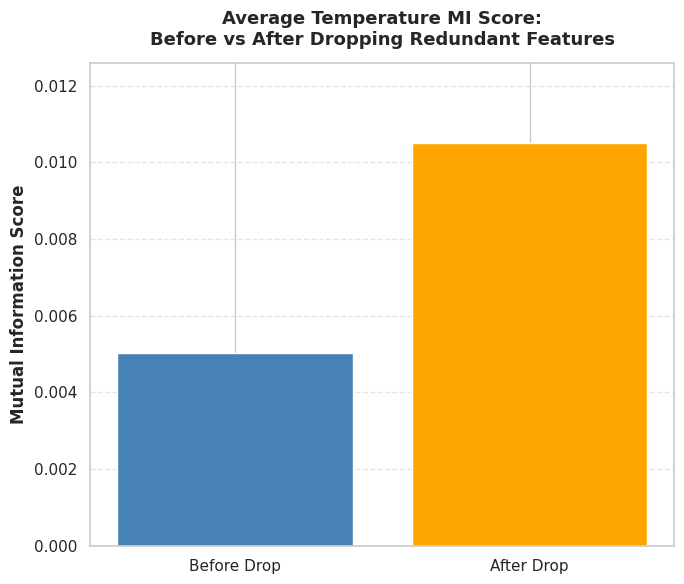

In [ ]:
# Visual comparison of mutual info score
plt.figure(figsize=(7, 6))
plt.bar(['Before Drop', 'After Drop'], [before, after], color=['steelblue', 'orange'])
plt.title("Average Temperature MI Score:\nBefore vs After Dropping Redundant Features",
          fontweight='bold', fontsize=13, pad=13)
plt.ylabel("Mutual Information Score", fontweight='bold')
plt.ylim(0, max(before, after) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

From the earlier MI output and the bar chart above, we can observe that the **mutual information score** for **Average Temperature (°C)** increased from **0.005020 to 0.010492** after removing the two redundant features—**Minimum Temperature (°C)** and **Maximum Temperature (°C)**.

This increase occurs because, previously, all three temperature features were **highly collinear** and **essentially competing to explain the same variance in the target variable**. As a result, their mutual information was **shared and diluted** across each other. By removing the two less informative features, **Average Temperature (°C)** is now able to express its contribution more clearly and directly—making it more useful and relevant for the model to better capture its true relationship with the target variable.

This increase in MI validates the decision to drop the redundant features, as it confirms that **Average Temperature (°C)** now holds a **stronger individual contribution** in explaining the target variable, without being masked or diluted by overlapping information from similar variables.

This outcome not only validates the redundancy detected earlier through VIF and MI analysis but also highlights the benefit of simplifying the feature set to improve individual feature strength and model interpretability.




###**7. Drop the Same Redundent Features in Test**

In [ ]:
# Drop redundant temp features from test data too
X_test_reduced = X_test_scaled.drop(columns=['Minimum Temperature (°C)', 'Maximum Temperature (°C)'])

print("'Minimum Temperature (°C)' and 'Maximum Temperature (°C)' features are dropped in X_test_reduced.")

'Minimum Temperature (°C)' and 'Maximum Temperature (°C)' features are dropped in X_test_reduced.


Since **Minimum Temperature (°C)** and **Maximum Temperature (°C)** were already removed from the training data due to redundancy, the **same features are also dropped from the test set** to ensure consistency between training and testing datasets. This keeps the structure of both sets aligned and avoids introducing unnecessary or unused features during prediction.




#**MODEL SELECTION**

In [ ]:
!pip install catboost

In [ ]:
# Import required libraries
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Define models to evaluate
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(verbose=-1),
    "CatBoost": CatBoostClassifier(verbose=0)
}

# Dictionary to store all results
results = {}

# Fit, predict, and evaluate each model
for name, model in models.items():
    model.fit(X_train_reduced, y_train)
    y_pred = model.predict(X_test_reduced)
    y_scores = model.predict_proba(X_test_reduced)[:, 1]  # Needed for AUC

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_scores)
    }

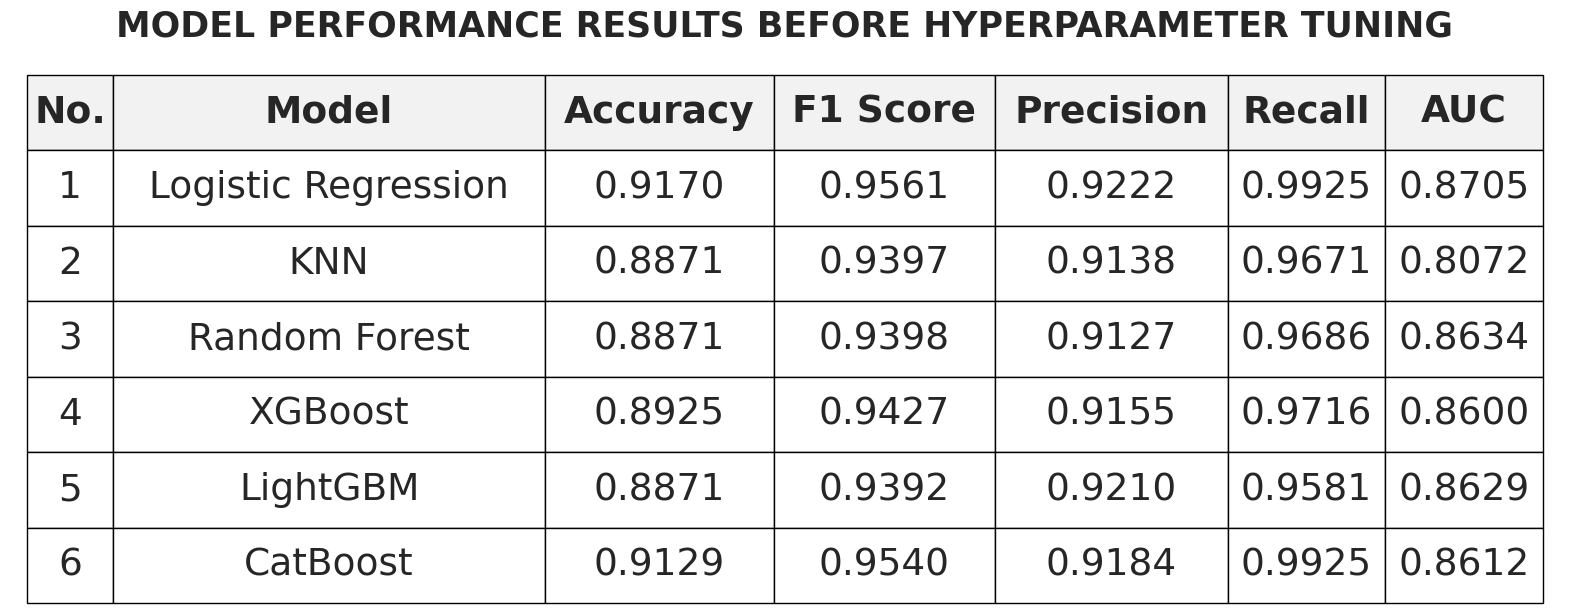

In [ ]:
# Display table of classification results
import matplotlib.pyplot as plt

# Step 1: Format data into table rows
table_data = []
for i, (model_name, metrics) in enumerate(results.items(), start=1):
    row = [i, model_name]
    for metric in ["Accuracy", "F1 Score", "Precision", "Recall", "AUC"]:
        row.append(f"{metrics[metric]:.4f}")
    table_data.append(row)

# Step 2: Define column headers
headers = ["No.", "Model", "Accuracy", "F1 Score", "Precision", "Recall", "AUC"]

# Step 3: Create figure
fig, ax = plt.subplots(figsize=(20, 2.8))  # Adjust width & height as needed
ax.axis("off")

# Step 4: Create table
table = ax.table(cellText=table_data, colLabels=headers, cellLoc="center", loc="center")

# Step 5: Styling
table.auto_set_font_size(False)
table.set_fontsize(27)
table.auto_set_column_width(col=list(range(len(headers))))

# Set cell height and header styling
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_height(0.35)
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#f2f2f2")

# Step 6: Add bold title
plt.title("MODEL PERFORMANCE RESULTS BEFORE HYPERPARAMETER TUNING", fontsize=25, fontweight="bold", pad=140)
plt.show()

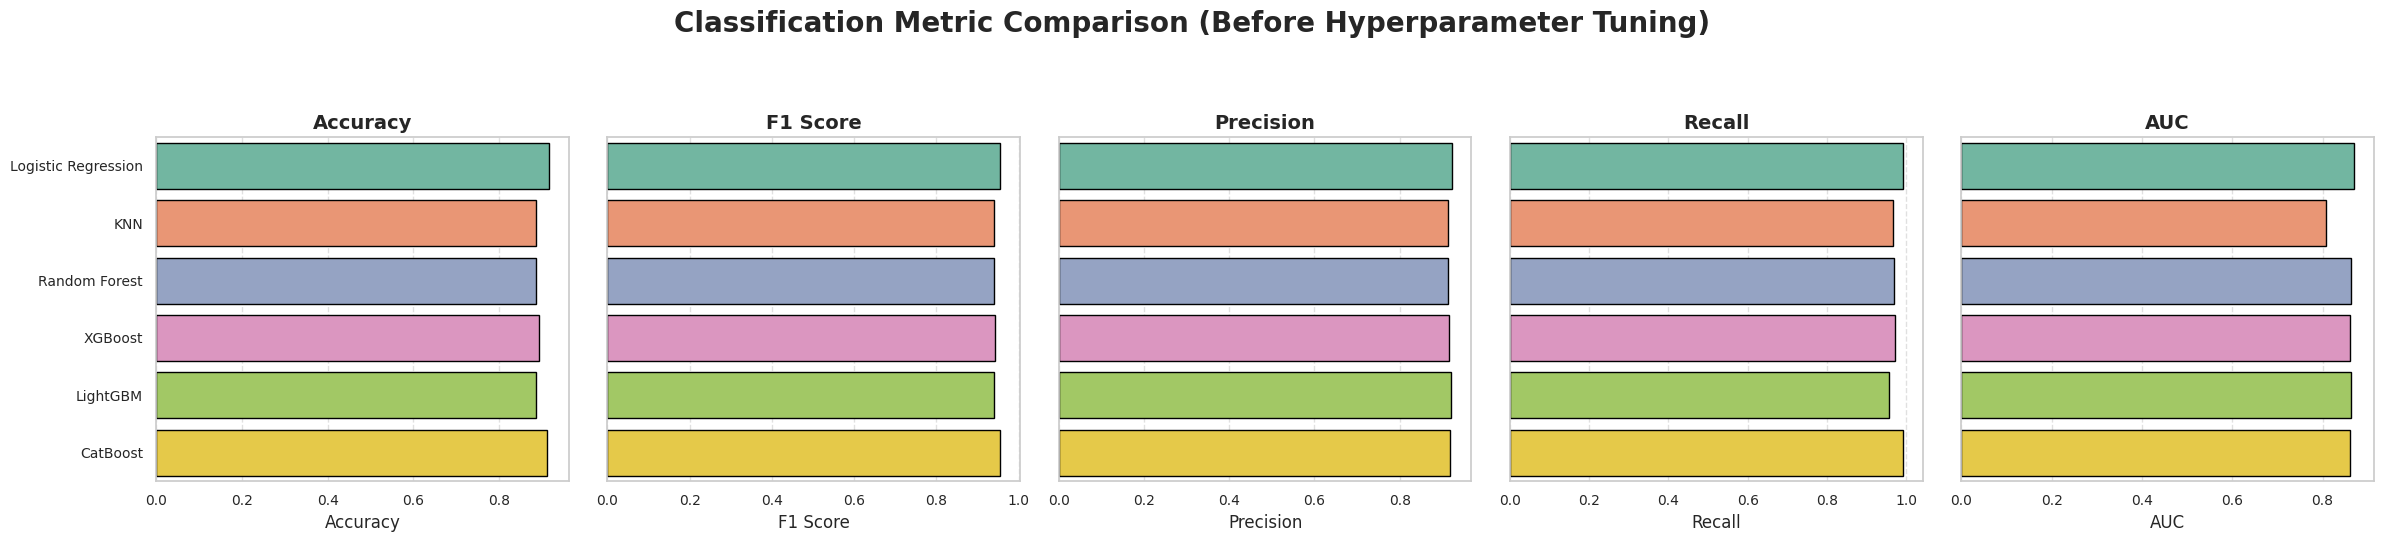

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Extract results for plotting
metrics_list = ["Accuracy", "F1 Score", "Precision", "Recall", "AUC"]
model_names = list(results.keys())

# Build a dictionary for each metric with values per model
metric_values = {
    metric: [results[model][metric] for model in model_names]
    for metric in metrics_list
}

# Define color palette for consistent styling
palette = sns.color_palette("Set2", len(model_names))

#  Plot one bar chart for each metric
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(24, 5), sharey=True)
fig.suptitle("Classification Metric Comparison (Before Hyperparameter Tuning)",
             fontsize=20, fontweight='bold', y=1.08)

for i, metric in enumerate(metrics_list):
    sns.barplot(
        x=metric_values[metric],
        y=model_names,
        palette=palette,
        ax=axes[i],
        edgecolor='black'
    )
    axes[i].set_title(metric, fontsize=14, fontweight='bold')
    axes[i].set_xlabel(metric, fontsize=12)
    axes[i].tick_params(axis='x', labelsize=10)
    axes[i].tick_params(axis='y', labelsize=10)
    axes[i].grid(axis='x', linestyle='--', alpha=0.6)

#  Tidy layout
plt.tight_layout()
plt.show()


#**MODEL TRAINING & HYPERPARAMETER TUNING**

##**Logistic Regression**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Define parameter grid
param_dist = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["liblinear", "saga"],
    "class_weight": [None, "balanced"]
}

# Stratified cross-validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize RandomizedSearchCV
log_reg = LogisticRegression(max_iter=1000)
random_search_auc = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=cv_strategy,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

# Fit search
random_search_auc.fit(X_train_reduced, y_train)

# Best estimator
best_log_model = random_search_auc.best_estimator_

# Display best parameters
print("✅ Best Hyperparameters for Logistic Regression (Tuned for AUC):")
print(random_search_auc.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
✅ Best Hyperparameters for Logistic Regression (Tuned for AUC):
{'solver': 'liblinear', 'penalty': 'l2', 'class_weight': None, 'C': 1}


In [ ]:
# Predict and get scores
y_pred = best_log_model.predict(X_test_reduced)
y_scores = best_log_model.predict_proba(X_test_reduced)[:, 1]

# Calculate performance metrics
logreg_tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "AUC": roc_auc_score(y_test, y_scores)
}

# Store into tuned_results
tuned_results = {}  # Define only once if not defined earlier
tuned_results["Logistic Regression (Tuned)"] = logreg_tuned_metrics

# Display the results
print("\nLogistic Regression - Tuned Performance")
for metric, value in logreg_tuned_metrics.items():
    print(f"{metric}: {value:.4f}")


Logistic Regression - Tuned Performance
Accuracy: 0.9184
F1 Score: 0.9568
Precision: 0.9223
Recall: 0.9940
AUC: 0.8705


## **KNN**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

# Define parameter grid for KNN
param_dist_knn = {
    "n_neighbors": [3, 5, 7, 9, 11, 13],
    "weights": ["uniform", "distance"],
    "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
    "leaf_size": [20, 30, 40, 50, 60],
    "p": [1, 2]  # 1 for Manhattan distance, 2 for Euclidean distance
}

# Stratified cross-validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize KNN classifier
knn = KNeighborsClassifier()

# Initialize RandomizedSearchCV for AUC
random_search_knn = RandomizedSearchCV(
    estimator=knn,
    param_distributions=param_dist_knn,
    n_iter=30,
    scoring='roc_auc',
    cv=cv_strategy,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

# Fit the RandomizedSearchCV on training data
random_search_knn.fit(X_train_reduced, y_train)

# Best estimator for KNN
best_knn_model = random_search_knn.best_estimator_

# Display best parameters for KNN
print("✅ Best Hyperparameters for KNN (Tuned for AUC):")
print(random_search_knn.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
✅ Best Hyperparameters for KNN (Tuned for AUC):
{'weights': 'uniform', 'p': 1, 'n_neighbors': 9, 'leaf_size': 40, 'algorithm': 'ball_tree'}


In [ ]:
# Predict and get scores
y_pred_knn = best_knn_model.predict(X_test_reduced)
y_scores_knn = best_knn_model.predict_proba(X_test_reduced)[:, 1]

# Calculate performance metrics for KNN
knn_tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "F1 Score": f1_score(y_test, y_pred_knn),
    "Precision": precision_score(y_test, y_pred_knn),
    "Recall": recall_score(y_test, y_pred_knn),
    "AUC": roc_auc_score(y_test, y_scores_knn)
}

# Store results for KNN
tuned_results["KNN (Tuned)"] = knn_tuned_metrics

# Display the results for KNN
print("\nKNN - Tuned Performance")
for metric, value in knn_tuned_metrics.items():
    print(f"{metric}: {value:.4f}")


KNN - Tuned Performance
Accuracy: 0.9061
F1 Score: 0.9505
Precision: 0.9132
Recall: 0.9910
AUC: 0.8182


## **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

# Define parameter grid for Random Forest
param_dist_rf = {
    "n_estimators": [50, 100, 150, 200, 250],
    "max_features": ["auto", "sqrt", "log2"],
    "max_depth": [None, 10, 20, 30, 40, 50],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True, False]
}

# Stratified cross-validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize Random Forest classifier
rf = RandomForestClassifier(random_state=42)

# Initialize RandomizedSearchCV for AUC
random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=30,
    scoring='roc_auc',
    cv=cv_strategy,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

# Fit the RandomizedSearchCV on training data
random_search_rf.fit(X_train_reduced, y_train)

# Best estimator for Random Forest
best_rf_model = random_search_rf.best_estimator_

# Display best parameters for Random Forest
print("✅ Best Hyperparameters for Random Forest (Tuned for AUC):")
print(random_search_rf.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
✅ Best Hyperparameters for Random Forest (Tuned for AUC):
{'n_estimators': 250, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 50, 'bootstrap': False}


In [ ]:
# Predict and get scores
y_pred_rf = best_rf_model.predict(X_test_reduced)
y_scores_rf = best_rf_model.predict_proba(X_test_reduced)[:, 1]

# Calculate performance metrics for Random Forest
rf_tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "AUC": roc_auc_score(y_test, y_scores_rf)
}

# Store results for Random Forest
tuned_results["Random Forest (Tuned)"] = rf_tuned_metrics

# Display the results for Random Forest
print("\nRandom Forest - Tuned Performance")
for metric, value in rf_tuned_metrics.items():
    print(f"{metric}: {value:.4f}")


Random Forest - Tuned Performance
Accuracy: 0.8912
F1 Score: 0.9424
Precision: 0.9096
Recall: 0.9776
AUC: 0.8794


##**LightGBM**

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Define parameter grid for LightGBM
param_dist_lgb = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'num_leaves': [20, 31, 40, 50],
    'max_depth': [-1, 5, 10, 15],
    'min_child_samples': [10, 20, 30],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
}

# Stratified 5-fold cross-validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize LightGBM classifier
lgbm = LGBMClassifier(random_state=42)

# Randomized search with AUC as the scoring metric
random_search_lgb = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist_lgb,
    n_iter=30,
    scoring='roc_auc',
    cv=cv_strategy,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Fit the model
random_search_lgb.fit(X_train_reduced, y_train)

# Get the best model
best_lgb_model = random_search_lgb.best_estimator_

# Display best parameters
print("✅ Best Hyperparameters for LightGBM (Tuned for AUC):")
print(random_search_lgb.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
✅ Best Hyperparameters for LightGBM (Tuned for AUC):
{'subsample': 0.6, 'num_leaves': 31, 'n_estimators': 100, 'min_child_samples': 10, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [ ]:
# Predict and get scores for LightGBM
y_pred = best_lgb_model.predict(X_test_reduced)
y_scores = best_lgb_model.predict_proba(X_test_reduced)[:, 1]

# Calculate performance metrics
lgbm_tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "AUC": roc_auc_score(y_test, y_scores)
}

# Store into tuned_results (initialize only once if not done before)
if 'tuned_results' not in globals():
    tuned_results = {}

tuned_results["LightGBM (Tuned)"] = lgbm_tuned_metrics

# Display the results
print("\nLightGBM - Tuned Performance")
for metric, value in lgbm_tuned_metrics.items():
    print(f"{metric}: {value:.4f}")


LightGBM - Tuned Performance
Accuracy: 0.9048
F1 Score: 0.9497
Precision: 0.9142
Recall: 0.9880
AUC: 0.8695


##**CatBoost**

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Define parameter grid for CatBoost
param_dist_cat = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'border_count': [32, 64, 128],
    'random_strength': [0.5, 1.0, 1.5],
}

# Stratified cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize CatBoostClassifier (silent mode)
cat_model = CatBoostClassifier(verbose=0, random_state=42)

# Initialize RandomizedSearchCV for CatBoost
random_search_cat = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=param_dist_cat,
    n_iter=30,
    scoring='roc_auc',
    cv=cv_strategy,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

# Fit search
random_search_cat.fit(X_train_reduced, y_train)

# Best estimator
best_cat_model = random_search_cat.best_estimator_

# Display best parameters
print("✅ Best Hyperparameters for CatBoost (Tuned for AUC):")
print(random_search_cat.best_params_)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
✅ Best Hyperparameters for CatBoost (Tuned for AUC):
{'random_strength': 0.5, 'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 300, 'depth': 8, 'border_count': 64}


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

# Predict and get scores
y_pred = best_cat_model.predict(X_test_reduced)
y_scores = best_cat_model.predict_proba(X_test_reduced)[:, 1]

# Calculate performance metrics
catboost_tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "AUC": roc_auc_score(y_test, y_scores)
}

# Store into tuned_results (initialize only once if not already)
if 'tuned_results' not in globals():
    tuned_results = {}

tuned_results["CatBoost (Tuned)"] = catboost_tuned_metrics

# Display the results
print("\nCatBoost - Tuned Performance")
for metric, value in catboost_tuned_metrics.items():
    print(f"{metric}: {value:.4f}")



CatBoost - Tuned Performance
Accuracy: 0.9048
F1 Score: 0.9496
Precision: 0.9166
Recall: 0.9851
AUC: 0.8577


##**XGBoost**

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Define parameter grid for XGBoost
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.5, 1],
    'reg_lambda': [1, 1.5, 2]
}

# Stratified K-Fold cross-validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize base XGBoost classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Set up RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=30,
    scoring='roc_auc',
    cv=cv_strategy,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

# Fit the model
random_search_xgb.fit(X_train_reduced, y_train)

# Best estimator
best_xgb_model = random_search_xgb.best_estimator_

# Display best hyperparameters
print("✅ Best Hyperparameters for XGBoost (Tuned for AUC):")
print(random_search_xgb.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
✅ Best Hyperparameters for XGBoost (Tuned for AUC):
{'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 1, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 1.0}


In [ ]:
# Predict and get scores
y_pred_xgb = best_xgb_model.predict(X_test_reduced)
y_scores_xgb = best_xgb_model.predict_proba(X_test_reduced)[:, 1]

# Calculate performance metrics for XGBoost
xgb_tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "F1 Score": f1_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "AUC": roc_auc_score(y_test, y_scores_xgb)
}

# Store results for XGBoost
tuned_results["XGBoost (Tuned)"] = xgb_tuned_metrics

# Display the results for XGBoost
print("\nXGBoost - Tuned Performance")
for metric, value in xgb_tuned_metrics.items():
    print(f"{metric}: {value:.4f}")


XGBoost - Tuned Performance
Accuracy: 0.9034
F1 Score: 0.9490
Precision: 0.9141
Recall: 0.9865
AUC: 0.8794


#**MODEL EVALUATION**

### Model Evaluation

In this section, we evaluate six classification models on five performance metrics:  
**AUC**, F1 Score, Precision, Recall, and Accuracy.

> ✅ **AUC** is our primary evaluation metric due to its robustness in handling imbalanced classes.  
> F1 Score is the secondary metric, balancing precision and recall.  
> Metrics are computed on the test set after tuning each model via `RandomizedSearchCV` with cross-validation.

We also visualize the results for easier comparison and determine which model performed best overall.


### Combine All Model Results

In [ ]:
# Combine results from all 6 tuned models
tuned_results = {
    "Logistic Regression (Tuned)": logreg_tuned_metrics,
    "KNN (Tuned)": knn_tuned_metrics,
    "Random Forest (Tuned)": rf_tuned_metrics,
    "LightGBM (Tuned)": lgbm_tuned_metrics,
    "CatBoost (Tuned)": catboost_tuned_metrics,
    "XGBoost (Tuned)": xgb_tuned_metrics
}


### Table of Results

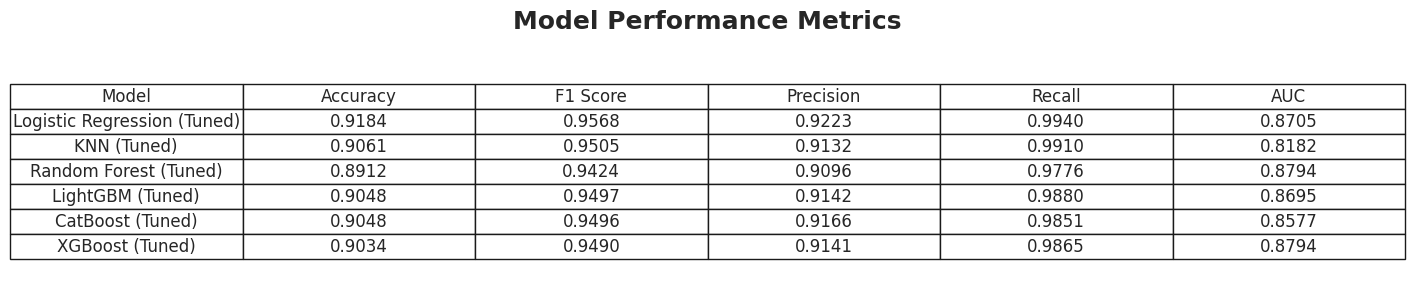

In [ ]:
import matplotlib.pyplot as plt

# Display results in a table
fig, ax = plt.subplots(figsize=(18, 3))
ax.axis('off')
table_data = [["Model"] + list(next(iter(tuned_results.values())).keys())]

for model, metrics in tuned_results.items():
    row = [model] + [f"{score:.4f}" for score in metrics.values()]
    table_data.append(row)

table = ax.table(cellText=table_data, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.5)
plt.title("Model Performance Metrics", fontsize=18, pad=20, fontweight="bold")
plt.show()


### Visualization of Each Metric

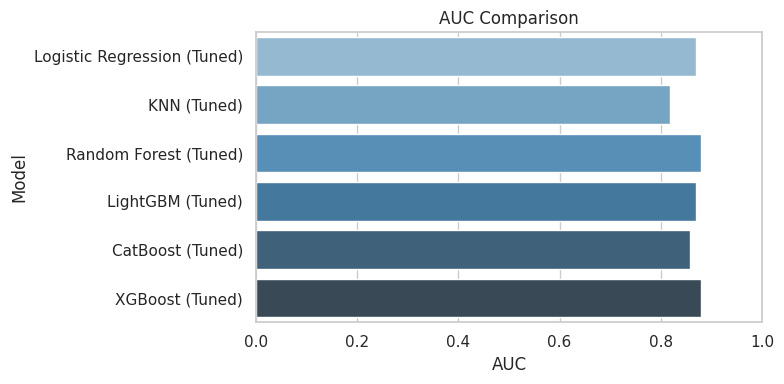

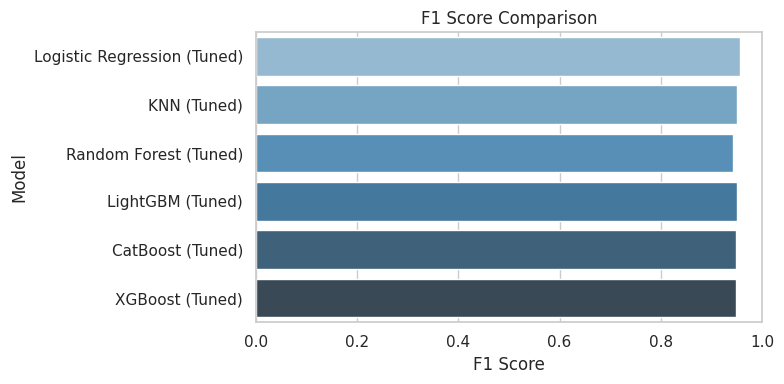

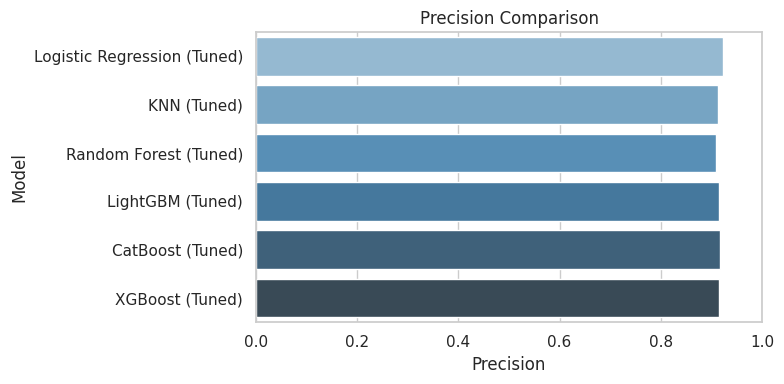

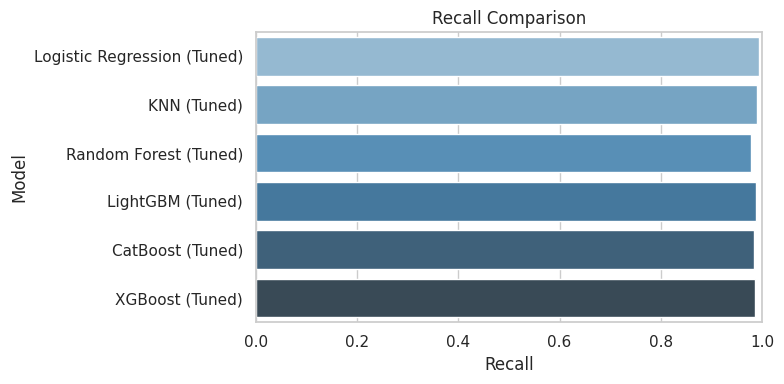

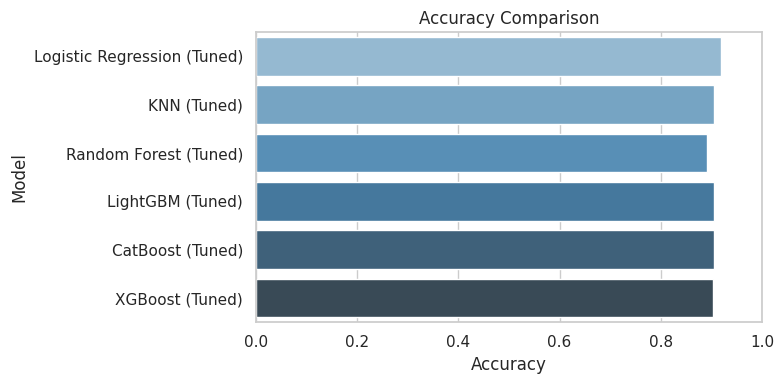

In [ ]:
import seaborn as sns
import pandas as pd

# Convert results to DataFrame for plotting
results_df = pd.DataFrame(tuned_results).T.reset_index().rename(columns={"index": "Model"})

# Plot each metric
metrics = ["AUC", "F1 Score", "Precision", "Recall", "Accuracy"]
for metric in metrics:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=results_df, x=metric, y="Model", palette="Blues_d")
    plt.title(f"{metric} Comparison")
    plt.xlim(0.0, 1.0)
    plt.tight_layout()
    plt.show()


### Best Model by AUC

In [ ]:
# Find the best model based on AUC
best_model = max(tuned_results.items(), key=lambda x: x[1]["AUC"])
print(f"Best Model Based on AUC: {best_model[0]} (AUC = {best_model[1]['AUC']:.4f})")


Best Model Based on AUC: Random Forest (Tuned) (AUC = 0.8794)


### Questions

#### Q1. What is the best evaluation method for your models?
We chose **AUC (Area Under the Curve)** as our primary evaluation metric.  
AUC is ideal for binary classification tasks, especially when class imbalance is present. It reflects how well the model can distinguish between positive and negative classes, regardless of threshold.

#### Q2. How do you compare your model to other models?
We compared all models based on five key metrics: **AUC, F1 Score, Precision, Recall, and Accuracy**.  
All models were tuned using cross-validation and evaluated on a held-out test set.  
Performance was visualized through tables and bar plots. AUC was used to determine the best model overall.
